# 0. 원본 로드 및 검증

In [ ]:
import pandas as pd
import numpy as np
import re
import itertools


train = pd.read_csv('/content/train_final.csv', encoding='utf-8-sig')

# 0-2. 형식 검증용 원본 사본 (타입 변환 전 문자열 보존, 이후 수정 금지)
train_raw = train.copy()

print('Train shape:', train.shape)

Train shape: (120000, 64)


In [ ]:
# 0-3. Fraud_Type 분포
target_col = 'Fraud_Type'
print('Fraud_Type value counts')
display(train[target_col].value_counts().sort_index())
print('Fraud_Type ratio (%)')
display((train[target_col].value_counts(normalize=True).sort_index() * 100).round(4).rename('ratio_percent'))

Fraud_Type value counts


,count
Fraud_Type,
a,100
b,100
c,100
d,100
e,100
f,100
g,100
h,100
i,100


Fraud_Type ratio (%)


,ratio_percent
Fraud_Type,
a,0.0833
b,0.0833
c,0.0833
d,0.0833
e,0.0833
f,0.0833
g,0.0833
h,0.0833
i,0.0833


In [ ]:
# 0-4. 전체 중복 행
print('Train duplicated rows:', train.duplicated().sum())

Train duplicated rows: 0


# 1. 컬럼 타입 명시 분류 및 변환

자동 키워드 매칭은 `First_time_iOS_by_vulnerable_user`(0/1 플래그)를 이름만 보고 datetime으로 오분류한다.
이후 단계 전체의 안정성을 위해 **명세서 기준 명시 리스트**로 고정한다.

In [ ]:
# 1-1. 명시적 타입 분류

target_col = "Fraud_Type"

# 진짜 datetime 6종
datetime_cols = [
    "Customer_registration_datetime",
    "Account_creation_datetime",
    "Transaction_Datetime",
    "Last_atm_transaction_datetime",
    "Last_bank_branch_transaction_datetime",
    "Transaction_resumed_date",
]

timedelta_cols = ["Time_difference"]

# 수치형 후보
numeric_like_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 0/1 플래그형 컬럼 자동 탐지
flag_cols = []
for col in numeric_like_cols:
    values = set(train[col].dropna().unique())
    if values.issubset({0, 1}):
        flag_cols.append(col)

# 플래그를 제외한 진짜 연속/금액/횟수 수치형
numeric_cols = [
    col for col in numeric_like_cols
    if col not in flag_cols
]

# 나머지는 범주형
categorical_cols = [
    col for col in train.columns
    if col not in numeric_cols
    + flag_cols
    + datetime_cols
    + timedelta_cols
    + [target_col]
]

# 오분류 방지: First_time_iOS_by_vulnerable_user는 플래그여야 함
assert "First_time_iOS_by_vulnerable_user" in flag_cols
assert "First_time_iOS_by_vulnerable_user" not in datetime_cols

print("datetime   :", len(datetime_cols), datetime_cols)
print("timedelta  :", len(timedelta_cols), timedelta_cols)
print("flag       :", len(flag_cols), flag_cols)
print("numeric    :", len(numeric_cols), numeric_cols)
print("categorical:", len(categorical_cols), categorical_cols)

total = (
    len(datetime_cols)
    + len(timedelta_cols)
    + len(flag_cols)
    + len(numeric_cols)
    + len(categorical_cols)
    + 1  # Fraud_Type
)

print("총 컬럼 수(train 기준, target 포함):", total)

datetime   : 6 ['Customer_registration_datetime', 'Account_creation_datetime', 'Transaction_Datetime', 'Last_atm_transaction_datetime', 'Last_bank_branch_transaction_datetime', 'Transaction_resumed_date']
timedelta  : 1 ['Time_difference']
flag       : 25 ['Customer_flag_change_of_authentication_1', 'Customer_flag_change_of_authentication_2', 'Customer_flag_change_of_authentication_3', 'Customer_flag_change_of_authentication_4', 'Customer_rooting_jailbreak_indicator', 'Customer_mobile_roaming_indicator', 'Customer_VPN_Indicator', 'Customer_flag_terminal_malicious_behavior_1', 'Customer_flag_terminal_malicious_behavior_2', 'Customer_flag_terminal_malicious_behavior_3', 'Customer_flag_terminal_malicious_behavior_4', 'Customer_flag_terminal_malicious_behavior_5', 'Customer_flag_terminal_malicious_behavior_6', 'Customer_inquery_atm_limit', 'Customer_increase_atm_limit', 'Account_indicator_release_limit_excess', 'Account_indicator_Openbanking', 'Account_release_suspention', 'Transaction_Fai

In [ ]:
# 1-2. 타입 변환
# datetime 6종 → datetime64
for col in datetime_cols:
    train[col] = pd.to_datetime(train[col], errors='coerce')

# Time_difference → timedelta → 초 단위 파생 (음수는 아직 보존: 아래 7단계에서 점검 후 처리)
train['Time_difference'] = pd.to_timedelta(train['Time_difference'], errors='coerce')
train['Time_difference_seconds'] = train['Time_difference'].dt.total_seconds()

print('Transaction_Datetime dtype:', train['Transaction_Datetime'].dtype)
print('First_time_iOS_by_vulnerable_user dtype (플래그 유지):', train['First_time_iOS_by_vulnerable_user'].dtype)
print('Time_difference_seconds 생성:', 'Time_difference_seconds' in train.columns)

Transaction_Datetime dtype: datetime64[ns]
First_time_iOS_by_vulnerable_user dtype (플래그 유지): int64
Time_difference_seconds 생성: True


In [ ]:
# 1-3. 타입 정리표
def role_of(col):
    if col == target_col: return 'target'
    if col in datetime_cols: return 'datetime'
    if col in timedelta_cols or col == 'Time_difference_seconds': return 'timedelta'
    if col in numeric_cols: return 'numeric'
    return 'categorical'

type_summary = pd.DataFrame({
    'column': train.columns,
    'dtype': train.dtypes.astype(str).values,
    'missing_count': train.isna().sum().values,
    'unique_count': train.nunique().values,
    'role': [role_of(c) for c in train.columns],
})
display(type_summary)

,column,dtype,missing_count,unique_count,role
0,ID,object,0,120000,categorical
1,Customer_Birthyear,int64,0,55,numeric
2,Customer_Gender,object,0,2,categorical
3,Customer_personal_identifier,object,0,1769,categorical
4,Customer_identification_number,object,0,4101,categorical
...,...,...,...,...,...
60,Transaction_history_with_the_account,int64,0,18,numeric
61,First_time_iOS_by_vulnerable_user,int64,0,2,categorical
62,Fraud_Type,object,0,13,target
63,Transaction_resumed_date,datetime64[ns],0,56200,datetime


# 2. 데이터 품질 점검

In [ ]:
# 2-1. 컬럼별 dtype / 결측 / 고유값
quality_overview = pd.DataFrame({
    'column': train.columns,
    'dtype': train.dtypes.astype(str).values,
    'missing_count': train.isna().sum().values,
    'missing_ratio': (train.isna().mean() * 100).round(4).values,
    'unique_count': train.nunique(dropna=False).values,
    'unique_ratio': (train.nunique(dropna=False) / len(train) * 100).round(4).values,
})
display(quality_overview)

,column,dtype,missing_count,missing_ratio,unique_count,unique_ratio
0,ID,object,0,0.0,120000,100.0000
1,Customer_Birthyear,int64,0,0.0,55,0.0458
2,Customer_Gender,object,0,0.0,2,0.0017
3,Customer_personal_identifier,object,0,0.0,1769,1.4742
4,Customer_identification_number,object,0,0.0,4101,3.4175
...,...,...,...,...,...,...
60,Transaction_history_with_the_account,int64,0,0.0,18,0.0150
61,First_time_iOS_by_vulnerable_user,int64,0,0.0,2,0.0017
62,Fraud_Type,object,0,0.0,13,0.0108
63,Transaction_resumed_date,datetime64[ns],0,0.0,56200,46.8333


In [ ]:
# 2-2. 결측 있는 컬럼만
missing_report = pd.DataFrame({
    'column': train.columns,
    'missing_count': train.isna().sum().values,
    'missing_ratio': (train.isna().mean() * 100).round(4).values,
})
display(missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False))
# 참고: Time_difference_seconds 의 결측(음수였던 값)은 아래 7단계 처리 후에 생긴다

,column,missing_count,missing_ratio


In [ ]:
# 2-3. 중복
print('Train duplicated rows :', train.duplicated().sum())
print('Train duplicated ratio:', round(train.duplicated().mean() * 100, 4), '%')

Train duplicated rows : 0
Train duplicated ratio: 0.0 %


## 3. 형식 검증 (원본 `train_raw` 기준)

타입 변환 후의 `train` 이 아니라 변환 전 문자열을 가진 `train_raw` 에서 검증해야 진짜 형식 위반이 잡힌다.


In [ ]:
# 3-1. datetime 파싱 실패 (원본 문자열 기준)
datetime_quality = []
for col in datetime_cols:
    s = train_raw[col]
    original_missing = int(s.isna().sum())
    if pd.api.types.is_datetime64_any_dtype(s):
        parse_fail_count, note = 0, '이미 datetime (원본 문자열 없음 → 검증 생략)'
    else:
        parsed = pd.to_datetime(s, errors='coerce')
        parse_fail_count = int((s.notna() & parsed.isna()).sum())   # 값이 있었는데 파싱 후 NaN = 형식 위반
        note = '문자열 파싱 검증'
    datetime_quality.append({
        'column': col, 'original_missing': original_missing,
        'parse_fail_count': parse_fail_count,
        'parse_fail_ratio_percent': round(parse_fail_count / len(train_raw) * 100, 4),
        'note': note,
    })
display(pd.DataFrame(datetime_quality).sort_values('parse_fail_count', ascending=False))

,column,original_missing,parse_fail_count,parse_fail_ratio_percent,note
0,Customer_registration_datetime,0,0,0.0,문자열 파싱 검증
1,Account_creation_datetime,0,0,0.0,문자열 파싱 검증
2,Transaction_Datetime,0,0,0.0,문자열 파싱 검증
3,Last_atm_transaction_datetime,0,0,0.0,문자열 파싱 검증
4,Last_bank_branch_transaction_datetime,0,0,0.0,문자열 파싱 검증
5,Transaction_resumed_date,0,0,0.0,문자열 파싱 검증


In [ ]:
# 3-2. Time_difference(timedelta) 파싱 실패 (원본 문자열 기준)
s = train_raw['Time_difference']
parsed = pd.to_timedelta(s, errors='coerce')
fail = int((s.notna() & parsed.isna()).sum())
print('Time_difference 형식 위반:', fail, '건')

Time_difference 형식 위반: 0 건


## 4. 음수 금액 점검 (방향 정보 vs 오류)

In [ ]:
# 4-1. 수치형 중 음수가 존재하는 컬럼
neg_report = []
for col in numeric_cols:
    s = train[col]
    neg = int((s < 0).sum())
    if neg > 0:
        neg_report.append({
            'column': col, 'negative_count': neg,
            'negative_ratio_percent': round((s < 0).mean() * 100, 4),
            'min': s.min(), 'max': s.max(),
        })
display(pd.DataFrame(neg_report).sort_values('negative_ratio_percent', ascending=False))
# 해석: Transaction_Amount 음수는 '오류'가 아니라 입출금 '방향' 가능성 → 이후 부호 분리 + 절댓값 보존 예정

,column,negative_count,negative_ratio_percent,min,max
2,Transaction_Amount,35817,29.8475,-382480000,406690000
0,Account_initial_balance,4152,3.4600,-47002364,378294259
1,Account_balance,1661,1.3842,-45756563,408024828


In [ ]:
# 4-2. Transaction_Amount 부호 분포
amt = train['Transaction_Amount']
sign_dist = pd.Series({'음수(<0)': (amt < 0).sum(), '0': (amt == 0).sum(), '양수(>0)': (amt > 0).sum()})
display(pd.DataFrame({'count': sign_dist, 'ratio_percent': (sign_dist / len(train) * 100).round(2)}))

,count,ratio_percent
음수(<0),35817,29.85
0,2018,1.68
양수(>0),82165,68.47


## 5. 날짜 현실성 점검 (시간기반 분할 적절성 — 기획서 H4)

In [ ]:
# 5-1. datetime 컬럼별 범위 / 미래(>2025) 비중
date_report = []
for col in datetime_cols:
    s = pd.to_datetime(train[col], errors='coerce')
    future = int((s.dt.year > 2025).sum())
    date_report.append({
        'column': col, 'min_date': s.min(), 'max_date': s.max(),
        'year_min': int(s.dt.year.min()), 'year_max': int(s.dt.year.max()),
        'future_count(>2025)': future,
        'future_ratio_percent': round(future / len(train) * 100, 4),
    })
display(pd.DataFrame(date_report))

,column,min_date,max_date,year_min,year_max,future_count(>2025),future_ratio_percent
0,Customer_registration_datetime,2003-01-05 11:03:41,2024-11-16 07:31:46,2003,2024,0,0.0000
1,Account_creation_datetime,2003-01-14 02:01:26,2024-12-01 17:06:38,2003,2024,0,0.0000
2,Transaction_Datetime,2003-01-25 22:20:34,2058-06-30 19:13:38,2003,2058,39133,32.6108
3,Last_atm_transaction_datetime,2003-01-21 21:29:08,2058-06-17 12:34:39,2003,2058,37341,31.1175
4,Last_bank_branch_transaction_datetime,2003-01-22 23:38:48,2058-06-24 12:21:34,2003,2058,37415,31.1792
5,Transaction_resumed_date,2003-01-19 21:29:08,2058-05-15 01:14:42,2003,2058,38796,32.3300


In [ ]:
# 5-2. 거래일자 연도 분포
tx_year = train['Transaction_Datetime'].dt.year
display(tx_year.value_counts().sort_index().rename('count'))
# 해석: 미래(2025 초과) 연도까지 분포 → 시간 순서가 무의미 → 시간기반 분할 부적절, 층화 분할 주력 (H4)

,count
Transaction_Datetime,
2003,487
2004,813
2005,1292
2006,1688
2007,2149
2008,2670
2009,3144
2010,3448
2011,4041


## 6. 고객/계좌 반복 & 그룹 누수 구조 (분할 전략 근거 — 기획서 5단계)


In [ ]:
# 6-1. 반복 구조
n_cust = train['Customer_identification_number'].nunique()
n_acc  = train['Account_account_number'].nunique()
print('고유 고객 수:', f'{n_cust:,}')
print('고유 계좌 수:', f'{n_acc:,}')
print('고객당 평균 거래수:', round(len(train) / n_cust, 1))

cust_acc = train.groupby('Customer_identification_number')['Account_account_number'].nunique()
print('\n고객당 계좌 수 분포:')
display(cust_acc.value_counts().rename('고객수'))

고유 고객 수: 4,101
고유 계좌 수: 4,101
고객당 평균 거래수: 29.3

고객당 계좌 수 분포:


,고객수
Account_account_number,
1,4101


In [ ]:
# 6-2. 정상/사기 양쪽에 등장하는 고객 (랜덤 분할 시 누수 위험)
fraud  = train[train['Fraud_Type'] != 'm']
normal = train[train['Fraud_Type'] == 'm']
both = set(fraud['Customer_identification_number']) & set(normal['Customer_identification_number'])
print('사기 행 수:', f'{len(fraud):,}')
print('사기에 등장한 고유 고객 수:', f"{fraud['Customer_identification_number'].nunique():,}")
print('정상·사기 양쪽에 등장하는 고객 수:', f'{len(both):,}')
# 해석: 같은 고객이 train/valid 양쪽에 들어가면 누수 → '층화' vs '고객 단위 그룹 분할' 결정 필요 (다음 단계)

사기 행 수: 1,200
사기에 등장한 고유 고객 수: 1,067
정상·사기 양쪽에 등장하는 고객 수: 966


## 7. `Time_difference_seconds` 정의 탐색 → 결론 → 처리

In [ ]:
# 7-1. 음수 케이스 점검 (처리 전)
neg_mask = train['Time_difference_seconds'] < 0
print('음수 건수:', int(neg_mask.sum()))
print('음수 최소(초):', train.loc[neg_mask, 'Time_difference_seconds'].min())
print('음수 최소(일 환산):', round(train.loc[neg_mask, 'Time_difference_seconds'].min() / 86400, 1))
display(train.loc[neg_mask, 'Fraud_Type'].value_counts())
display(train.loc[neg_mask, ['Time_difference', 'Time_difference_seconds']].head())

음수 건수: 156
음수 최소(초): -1045256012.0
음수 최소(일 환산): -12097.9


,count
Fraud_Type,
m,154
a,2


,Time_difference,Time_difference_seconds
74,-11381 days +21:39:31,-983240429.0
84,-7993 days +05:48:41,-690574279.0
111,-8775 days +10:23:42,-758122578.0
208,-1971 days +07:08:21,-170268699.0
224,-1536 days +15:53:02,-132653218.0


In [ ]:
# 7-4. 분포 + 유형별 중앙값 (피처 가치 근거)
display(train['Time_difference_seconds'].describe(percentiles=[.01, .05, .5, .95, .99]))
display(train.groupby('Fraud_Type')['Time_difference_seconds'].median())

,Time_difference_seconds
count,1.200000e+05
mean,7.578565e+05
std,2.003843e+07
min,-1.045256e+09
1%,2.250000e+02
5%,9.789500e+02
50%,9.169500e+03
95%,5.884124e+05
99%,3.198631e+07
max,3.214080e+07


,Time_difference_seconds
Fraud_Type,
a,3222.0
b,8815.0
c,8451.5
d,9166.0
e,8594.5
f,7411.5
g,8669.0
h,161564.0
i,9403.0


### 결론

음수 156건(대부분 정상 m, 최소 ≈-33년)은 비물리적이므로 **절댓값 대신 결측(NaN)** 처리 → LightGBM이 결측을 분기로 흡수.
**주의: `test.csv` 처리 시에도 동일하게 '음수 → NaN' 을 적용해야 일관성이 유지된다.**

In [ ]:
# 7-5. 결정 적용: 음수 → NaN, 중복인 timedelta 원본 컬럼 드롭
train.loc[train['Time_difference_seconds'] < 0, 'Time_difference_seconds'] = np.nan
print('음수 → NaN 처리 후 결측 수:', int(train['Time_difference_seconds'].isna().sum()))

if 'Time_difference' in train.columns:
    train = train.drop(columns=['Time_difference'])
print('남은 컬럼 수:', train.shape[1])

음수 → NaN 처리 후 결측 수: 156
남은 컬럼 수: 64


### 7-6. datetime 컬럼 재검증 (오분류 재발 방지 재확인)

In [ ]:
# 8-1. datetime 으로 잡힌 컬럼이 실제로 날짜형인지 (오분류 재발 방지)
print('=== datetime_cols 원본 dtype 점검 ===')
for col in datetime_cols:
    rd = train_raw[col].dtype
    textlike = pd.api.types.is_object_dtype(rd) or pd.api.types.is_string_dtype(rd)
    ok = textlike or pd.api.types.is_datetime64_any_dtype(rd)
    print(f'{col:45s} 원본 {str(rd):20s}' + ('' if ok else '  <-- 의심(날짜 아님)'))

# 8-2. 최종 train 컬럼 목록
print('\n=== 최종 train 컬럼 목록 ===')
for i, col in enumerate(train.columns):
    print(f'{i:2d}  {col:48s} {train[col].dtype}')

=== datetime_cols 원본 dtype 점검 ===
Customer_registration_datetime                원본 object              
Account_creation_datetime                     원본 object              
Transaction_Datetime                          원본 object              
Last_atm_transaction_datetime                 원본 object              
Last_bank_branch_transaction_datetime         원본 object              
Transaction_resumed_date                      원본 object              

=== 최종 train 컬럼 목록 ===
 0  ID                                               object
 1  Customer_Birthyear                               int64
 2  Customer_Gender                                  object
 3  Customer_personal_identifier                     object
 4  Customer_identification_number                   object
 5  Customer_registration_datetime                   datetime64[ns]
 6  Customer_credit_rating                           object
 7  Customer_flag_change_of_authentication_1         int64
 8  Customer_flag_change_of_authenti

## 8. 금액 부호 분리

In [ ]:
# 전체 수치형 컬럼 중 음수값이 있는 컬럼 조회

numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns

negative_report = []

for col in numeric_cols:
    negative_count = (train[col] < 0).sum()

    if negative_count > 0:
        negative_report.append({
            "column": col,
            "negative_count": negative_count,
            "negative_ratio_percent": round(negative_count / len(train) * 100, 4),
            "min_value": train[col].min()
        })

negative_report = pd.DataFrame(negative_report)

display(negative_report.sort_values("negative_count", ascending=False))

,column,negative_count,negative_ratio_percent,min_value
2,Transaction_Amount,35817,29.8475,-382480000
0,Account_initial_balance,4152,3.4600,-47002364
1,Account_balance,1661,1.3842,-45756563


In [ ]:
# Transaction_Amount 부호 분리 + 절댓값 컬럼 생성

amount_col = "Transaction_Amount"

# 출금/입금 이진 컬럼
# 1 = 출금(음수 거래금액)
# 0 = 입금(0 이상 거래금액)
train["Transaction_is_withdrawal"] = (train[amount_col] < 0).astype(int)

# 거래금액 절댓값 컬럼
train["Transaction_Amount_abs"] = train[amount_col].abs()

In [ ]:
display(
    train[[amount_col, "Transaction_is_withdrawal", "Transaction_Amount_abs"]]
    .head(20)
)

,Transaction_Amount,Transaction_is_withdrawal,Transaction_Amount_abs
0,10000,0,10000
1,-25160000,1,25160000
2,20130000,0,20130000
3,24620000,0,24620000
4,-30000,1,30000
5,29390000,0,29390000
6,17720000,0,17720000
7,-120000,1,120000
8,12980000,0,12980000
9,12640000,0,12640000


In [ ]:
if 'Transaction_Amount' in train.columns:
    train = train.drop(columns=['Transaction_Amount'])
print('남은 컬럼 수:', train.shape[1])

남은 컬럼 수: 65


### 8-5. Location → Location_region 지역 파생

In [ ]:
def extract_region(location):
    if pd.isna(location):
        return "unknown"

    parts = str(location).strip().split()

    if len(parts) >= 1:
        return parts[0]

    return "unknown"


train["Location_region"] = train["Location"].apply(extract_region)

train = train.drop(columns=["Location"])

print(train[["Location_region"]].head())
print("Location 컬럼 존재 여부:", "Location" in train.columns)
print("Location_region 고유값 수:", train["Location_region"].nunique())
print(train["Location_region"].value_counts().head(20))

  Location_region
0             강원도
1            경상북도
2            경상북도
3            경상북도
4            경상남도
Location 컬럼 존재 여부: False
Location_region 고유값 수: 17
Location_region
경기도        18411
경상북도       14692
충청북도       14423
충청남도       12200
전라남도       12181
강원도        11351
경상남도       10077
전라북도        8016
서울특별시       4275
대구광역시       2745
인천광역시       2371
부산광역시       2190
광주광역시       1877
울산광역시       1670
대전광역시       1587
세종특별자치시     1315
제주특별자치도      619
Name: count, dtype: int64


# 9. 학습/검증 분할 확정 (StratifiedGroupKFold, 80/20)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

SEED = 42
N_SPLITS = 5

# 타깃 결측 확인
print("Fraud_Type 결측 수:", train["Fraud_Type"].isna().sum())
assert train["Fraud_Type"].notna().all(), "Fraud_Type에 결측이 있습니다."

# sklearn에 넣기 전에 pandas <NA>가 아닌 일반 문자열 배열로 변환
y = train["Fraud_Type"].astype(str).to_numpy()

groups = (
    train["Customer_identification_number"]
    .where(train["Customer_identification_number"].notna(), "__MISSING_CUSTOMER__")
    .astype(str)
    .to_numpy()
)

sgkf = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

tr_idx, va_idx = next(sgkf.split(train, y, groups))

df_tr = train.iloc[tr_idx].copy()
df_va = train.iloc[va_idx].copy()

print(f"train: {len(df_tr):,}건 / valid: {len(df_va):,}건 "
      f"(valid 비율 {len(df_va)/len(train)*100:.1f}%)")

Fraud_Type 결측 수: 0
train: 96,140건 / valid: 23,860건 (valid 비율 19.9%)


In [ ]:
# 검증: (1) 고객 누수 0건  (2) 계좌 누수 0건  (3) 13개 클래스 양쪽 분포

customer_overlap = (
    set(df_tr["Customer_identification_number"].dropna())
    & set(df_va["Customer_identification_number"].dropna())
)

account_overlap = (
    set(df_tr["Account_account_number"].dropna())
    & set(df_va["Account_account_number"].dropna())
)

print("고객 누수(교집합):", len(customer_overlap), "명   ->  0 이어야 정상")
print("계좌 누수(교집합):", len(account_overlap), "개   ->  0 이어야 정상")

assert len(customer_overlap) == 0, "고객 누수 발생: train/valid에 같은 고객이 존재합니다."
assert len(account_overlap) == 0, "계좌 누수 발생: train/valid에 같은 계좌가 존재합니다."

dist = pd.DataFrame({
    "train": df_tr["Fraud_Type"].value_counts().sort_index(),
    "valid": df_va["Fraud_Type"].value_counts().sort_index(),
}).fillna(0).astype(int)

dist["valid_ratio_%"] = (
    dist["valid"] / (dist["train"] + dist["valid"]) * 100
).round(1)

display(dist)

missing_valid_classes = dist.index[dist["valid"] == 0].tolist()
print("valid에 0건인 클래스:", missing_valid_classes or "없음")

assert len(missing_valid_classes) == 0, "valid에 존재하지 않는 Fraud_Type 클래스가 있습니다."

고객 누수(교집합): 0 명   ->  0 이어야 정상
계좌 누수(교집합): 0 개   ->  0 이어야 정상


,train,valid,valid_ratio_%
Fraud_Type,,,
a,77,23,23.0
b,78,22,22.0
c,73,27,27.0
d,84,16,16.0
e,77,23,23.0
f,84,16,16.0
g,72,28,28.0
h,80,20,20.0
i,77,23,23.0


valid에 0건인 클래스: 없음


## 10 .1차 EDA 사기 변별 관점 탐색 — `df_tr` 기준

파생변수를 만들기 전에 **어떤 변수가 사기를 가르는지** 확인해 파생 방향을 정한다.
- 반드시 `df_tr` 에서만 본다 (valid를 보고 설계하면 누수).
- 범주형이 아직 라벨 상태라 의미를 그대로 읽을 수 있다.

In [ ]:
# 1차 EDA는 df_tr 에서만 — valid를 보고 설계하면 누수
eda = df_tr.copy()
eda["is_fraud"] = (eda["Fraud_Type"] != "m").astype(int)

num_cols_eda = [c for c in [
    "Transaction_Amount_abs", "Account_balance", "Account_amount_daily_limit",
    "Account_one_month_max_amount", "Distance", "Time_difference_seconds",
    "Number_of_transaction_with_the_account", "Transaction_history_with_the_account",
] if c in eda.columns]

In [ ]:
# 0/1 플래그의 정상 vs 사기 발생률 차이 (클수록 변별력 있는 위협 신호)
flag_cols = [c for c in eda.columns
             if c != "is_fraud" and eda[c].dropna().isin([0, 1]).all() and eda[c].nunique() <= 2]
rate = eda.groupby("is_fraud")[flag_cols].mean().T
rate.columns = ["정상(m)", "사기"]
rate["차이(사기-정상)"] = rate["사기"] - rate["정상(m)"]
display(rate.sort_values("차이(사기-정상)", ascending=False).round(4))

,정상(m),사기,차이(사기-정상)
Transaction_is_withdrawal,0.2925,0.9469,0.6544
Flag_deposit_more_than_tenMillion,0.4238,0.5658,0.1420
Account_release_suspention,0.6399,0.6890,0.0491
Customer_rooting_jailbreak_indicator,0.0728,0.1178,0.0451
Customer_flag_terminal_malicious_behavior_6,0.1427,0.1794,0.0368
Customer_flag_terminal_malicious_behavior_2,0.0961,0.1210,0.0250
Transaction_Failure_Status,0.0234,0.0403,0.0169
Customer_VPN_Indicator,0.0724,0.0849,0.0125
Account_indicator_release_limit_excess,0.2017,0.2134,0.0117
Recipient_account_suspend_status,0.4924,0.4979,0.0055


In [ ]:
#withdrawal,deposit 같이
target = "Fraud_Type"
deposit = "Flag_deposit_more_than_tenMillion"
withdrawal = "Transaction_is_withdrawal"

combo_by_class = (
    eda.groupby([target, withdrawal, deposit])
      .size()
      .reset_index(name="n")
)

combo_by_class["class_total"] = combo_by_class.groupby(target)["n"].transform("sum")
combo_by_class["rate_in_class"] = combo_by_class["n"] / combo_by_class["class_total"]

combo_by_class.sort_values([target, "rate_in_class"], ascending=[True, False])

,Fraud_Type,Transaction_is_withdrawal,Flag_deposit_more_than_tenMillion,n,class_total,rate_in_class
0,a,0,0,29,77,0.376623
1,a,0,1,21,77,0.272727
2,a,1,0,14,77,0.181818
3,a,1,1,13,77,0.168831
4,b,1,0,50,78,0.641026
5,b,1,1,28,78,0.358974
6,c,1,0,40,73,0.547945
7,c,1,1,33,73,0.452055
8,d,1,0,57,84,0.678571
9,d,1,1,27,84,0.321429


In [ ]:
# 범주형이 유형별로 갈리는지 (행 정규화, 사기 유형만)
for c in ['Customer_Gender', 'Customer_credit_rating', 'Customer_loan_type', 'Account_account_type', 'Channel', 'Operating_System', 'Error_Code', 'Type_General_Automatic', 'Access_Medium', 'Location_region']:
    if c in eda.columns:
        print(f"\n=== Fraud_Type × {c} (행 정규화, 사기 유형만) ===")
        ct = pd.crosstab(eda["Fraud_Type"], eda[c], normalize="index")
        display(ct.loc[ct.index != "m"].round(3))



=== Fraud_Type × Customer_Gender (행 정규화, 사기 유형만) ===


Customer_Gender,female,male
Fraud_Type,,
a,0.519,0.481
b,0.577,0.423
c,0.438,0.562
d,0.583,0.417
e,0.519,0.481
f,0.619,0.381
g,0.500,0.500
h,0.488,0.512
i,0.623,0.377



=== Fraud_Type × Customer_credit_rating (행 정규화, 사기 유형만) ===


Customer_credit_rating,A,B,C,D,E,S
Fraud_Type,,,,,,
a,0.208,0.416,0.247,0.013,0.026,0.091
b,0.000,0.000,0.564,0.205,0.231,0.000
c,0.192,0.411,0.205,0.096,0.000,0.096
d,0.107,0.524,0.238,0.048,0.048,0.036
e,0.260,0.442,0.169,0.026,0.052,0.052
f,0.238,0.417,0.238,0.024,0.048,0.036
g,0.292,0.431,0.167,0.042,0.056,0.014
h,0.162,0.588,0.175,0.038,0.012,0.025
i,0.234,0.455,0.156,0.091,0.026,0.039



=== Fraud_Type × Customer_loan_type (행 정규화, 사기 유형만) ===


...

Type_General_Automatic,automatic,general
Fraud_Type,,
a,0.052,0.948
b,0.000,1.000
c,0.000,1.000
d,0.000,1.000
e,0.000,1.000
f,0.000,1.000
g,0.000,1.000
h,0.000,1.000
i,0.000,1.000



=== Fraud_Type × Access_Medium (행 정규화, 사기 유형만) ===


Access_Medium,a,b,c,d,e,f,g
Fraud_Type,,,,,,,
a,0.403,0.494,0.000,0.013,0.039,0.026,0.026
b,0.538,0.462,0.000,0.000,0.000,0.000,0.000
c,0.356,0.493,0.014,0.027,0.055,0.014,0.041
d,0.536,0.464,0.000,0.000,0.000,0.000,0.000
e,0.299,0.455,0.026,0.065,0.065,0.078,0.013
f,0.369,0.452,0.024,0.036,0.048,0.024,0.048
g,0.347,0.472,0.042,0.042,0.056,0.042,0.000
h,0.450,0.388,0.025,0.000,0.062,0.038,0.038
i,0.325,0.545,0.000,0.000,0.078,0.039,0.013



=== Fraud_Type × Location_region (행 정규화, 사기 유형만) ===


Location_region,강원도,경기도,경상남도,경상북도,광주광역시,대구광역시,대전광역시,부산광역시,서울특별시,세종특별자치시,울산광역시,인천광역시,전라남도,전라북도,제주특별자치도,충청남도,충청북도
Fraud_Type,,,,,,,,,,,,,,,,,
a,0.208,0.117,0.078,0.026,0.026,0.000,0.013,0.039,0.091,0.000,0.052,0.039,0.195,0.013,0.052,0.013,0.039
b,0.051,0.128,0.103,0.115,0.026,0.013,0.000,0.026,0.038,0.000,0.026,0.026,0.128,0.103,0.000,0.090,0.128
c,0.068,0.110,0.110,0.151,0.000,0.000,0.027,0.041,0.041,0.014,0.000,0.000,0.096,0.041,0.000,0.178,0.123
d,0.167,0.155,0.119,0.190,0.000,0.012,0.024,0.012,0.024,0.012,0.024,0.012,0.083,0.024,0.000,0.071,0.071
e,0.052,0.156,0.130,0.091,0.013,0.026,0.013,0.026,0.065,0.013,0.000,0.026,0.117,0.039,0.026,0.104,0.104
f,0.143,0.107,0.095,0.107,0.000,0.000,0.012,0.036,0.048,0.012,0.024,0.000,0.071,0.131,0.000,0.107,0.107
g,0.111,0.167,0.056,0.153,0.028,0.000,0.014,0.014,0.014,0.014,0.000,0.000,0.083,0.042,0.000,0.139,0.167
h,0.150,0.075,0.062,0.088,0.012,0.012,0.012,0.000,0.025,0.012,0.025,0.038,0.100,0.050,0.025,0.125,0.188
i,0.039,0.130,0.169,0.078,0.026,0.000,0.013,0.026,0.013,0.000,0.013,0.039,0.143,0.078,0.000,0.104,0.130


### 10-4. Fraud_Type별 Location_region 비율표

In [ ]:
# 1. Fraud_Type별 Location_region 비율표
location_region_ratio = pd.crosstab(
    train["Fraud_Type"],
    train["Location_region"],
    normalize="index"
).round(3)

display(location_region_ratio)

# 2. 정상 m 기준 차이 계산
normal_region_ratio = location_region_ratio.loc["m"]

fraud_vs_normal_region = location_region_ratio.drop(index="m").sub(
    normal_region_ratio,
    axis=1
).round(3)

display(fraud_vs_normal_region)

# 3. 유형별 정상 대비 높은 지역 TOP 5
for fraud_type in fraud_vs_normal_region.index:
    print(f"\n=== Fraud_Type {fraud_type}: 정상 m 대비 높은 지역 TOP 5 ===")
    display(
        fraud_vs_normal_region.loc[fraud_type]
        .sort_values(ascending=False)
        .head(5)
    )

Location_region,강원도,경기도,경상남도,경상북도,광주광역시,대구광역시,대전광역시,부산광역시,서울특별시,세종특별자치시,울산광역시,인천광역시,전라남도,전라북도,제주특별자치도,충청남도,충청북도
Fraud_Type,,,,,,,,,,,,,,,,,
a,0.190,0.110,0.090,0.030,0.030,0.000,0.010,0.030,0.070,0.000,0.040,0.04,0.200,0.020,0.070,0.010,0.06
b,0.060,0.150,0.090,0.110,0.020,0.030,0.000,0.020,0.030,0.000,0.020,0.04,0.120,0.080,0.000,0.110,0.12
c,0.060,0.150,0.090,0.140,0.000,0.000,0.020,0.050,0.040,0.010,0.010,0.00,0.100,0.030,0.000,0.190,0.11
d,0.140,0.140,0.110,0.180,0.000,0.020,0.020,0.010,0.020,0.010,0.040,0.01,0.100,0.020,0.000,0.080,0.10
e,0.090,0.130,0.150,0.120,0.010,0.020,0.010,0.020,0.060,0.020,0.000,0.02,0.120,0.050,0.020,0.080,0.08
f,0.130,0.110,0.080,0.130,0.000,0.000,0.010,0.040,0.040,0.010,0.030,0.00,0.090,0.110,0.000,0.110,0.11
g,0.100,0.180,0.050,0.170,0.020,0.020,0.010,0.020,0.010,0.010,0.000,0.01,0.060,0.070,0.000,0.130,0.14
h,0.130,0.120,0.080,0.090,0.010,0.030,0.010,0.000,0.020,0.010,0.020,0.03,0.090,0.040,0.020,0.110,0.19
i,0.040,0.160,0.150,0.100,0.020,0.000,0.020,0.030,0.010,0.000,0.010,0.04,0.120,0.090,0.000,0.090,0.12


Location_region,강원도,경기도,경상남도,경상북도,광주광역시,대구광역시,대전광역시,부산광역시,서울특별시,세종특별자치시,울산광역시,인천광역시,전라남도,전라북도,제주특별자치도,충청남도,충청북도
Fraud_Type,,,,,,,,,,,,,,,,,
a,0.095,-0.044,0.006,-0.092,0.014,-0.023,-0.003,0.012,0.034,-0.011,0.026,0.02,0.099,-0.047,0.065,-0.092,-0.06
b,-0.035,-0.004,0.006,-0.012,0.004,0.007,-0.013,0.002,-0.006,-0.011,0.006,0.02,0.019,0.013,-0.005,0.008,0.00
c,-0.035,-0.004,0.006,0.018,-0.016,-0.023,0.007,0.032,0.004,-0.001,-0.004,-0.02,-0.001,-0.037,-0.005,0.088,-0.01
d,0.045,-0.014,0.026,0.058,-0.016,-0.003,0.007,-0.008,-0.016,-0.001,0.026,-0.01,-0.001,-0.047,-0.005,-0.022,-0.02
e,-0.005,-0.024,0.066,-0.002,-0.006,-0.003,-0.003,0.002,0.024,0.009,-0.014,0.00,0.019,-0.017,0.015,-0.022,-0.04
f,0.035,-0.044,-0.004,0.008,-0.016,-0.023,-0.003,0.022,0.004,-0.001,0.016,-0.02,-0.011,0.043,-0.005,0.008,-0.01
g,0.005,0.026,-0.034,0.048,0.004,-0.003,-0.003,0.002,-0.026,-0.001,-0.014,-0.01,-0.041,0.003,-0.005,0.028,0.02
h,0.035,-0.034,-0.004,-0.032,-0.006,0.007,-0.003,-0.018,-0.016,-0.001,0.006,0.01,-0.011,-0.027,0.015,0.008,0.07
i,-0.055,0.006,0.066,-0.022,0.004,-0.023,0.007,0.012,-0.026,-0.011,-0.004,0.02,0.019,0.023,-0.005,-0.012,0.00



=== Fraud_Type a: 정상 m 대비 높은 지역 TOP 5 ===


,a
Location_region,
전라남도,0.099
강원도,0.095
제주특별자치도,0.065
서울특별시,0.034
울산광역시,0.026



=== Fraud_Type b: 정상 m 대비 높은 지역 TOP 5 ===


...

,j
Location_region,
전라남도,0.049
경상남도,0.036
강원도,0.025
전라북도,0.023
인천광역시,0.010



=== Fraud_Type k: 정상 m 대비 높은 지역 TOP 5 ===


,k
Location_region,
서울특별시,0.044
울산광역시,0.026
강원도,0.025
전라북도,0.013
부산광역시,0.012



=== Fraud_Type l: 정상 m 대비 높은 지역 TOP 5 ===


,l
Location_region,
경상북도,0.028
서울특별시,0.024
충청북도,0.020
충청남도,0.018
제주특별자치도,0.015


### 10-5. 수치형 변수 Kruskal-Wallis 스크리닝 (13그룹 동시비교, 효과크기 희석 주의)

In [ ]:
#수치형 크루스칼 검정, 효과크기
import numpy as np
import pandas as pd
from scipy.stats import kruskal

num_cols = [
    'Customer_Birthyear',
    'Account_initial_balance',
    'Account_balance',
    'Account_amount_daily_limit',
    'Account_remaining_amount_daily_limit_exceeded',
    'Account_one_month_max_amount',
    'Account_one_month_std_dev',
    'Account_dawn_one_month_max_amount',
    'Account_dawn_one_month_std_dev',
    'Transaction_num_connection_failure',
    'Distance',
    'Number_of_transaction_with_the_account',
    'Transaction_history_with_the_account',
    'Time_difference_seconds',
    'Transaction_Amount_abs'
]

target_col = 'Fraud_Type'

def epsilon_squared_kruskal(h_stat, n, k):
    """
    Kruskal-Wallis effect size: epsilon-squared.
    값이 클수록 Fraud_Type별 분포 차이가 큼.
    """
    if n <= k:
        return np.nan
    return (h_stat - k + 1) / (n - k)

def effect_size_label(eps):
    """
    일반적인 참고 기준.
    맥락에 따라 절대 기준으로 과해석하지 않는 것이 좋음.
    """
    if pd.isna(eps):
        return 'nan'
    elif eps < 0.01:
        return 'negligible'
    elif eps < 0.06:
        return 'small'
    elif eps < 0.14:
        return 'medium'
    else:
        return 'large'

results = []

for col in num_cols:
    temp = train[[target_col, col]].dropna()

    groups = [
        group[col].values
        for _, group in temp.groupby(target_col)
    ]

    k = len(groups)
    n = len(temp)

    if k < 2:
        h_stat = np.nan
        p_value = np.nan
        eps_sq = np.nan
    else:
        h_stat, p_value = kruskal(*groups)
        eps_sq = epsilon_squared_kruskal(h_stat, n, k)

    results.append({
        'feature': col,
        'kruskal_h_stat': h_stat,
        'kruskal_p_value': p_value,
        'epsilon_squared': eps_sq,
        'effect_size': effect_size_label(eps_sq),
        'n_samples': n,
        'n_groups': k
    })

kruskal_result = (
    pd.DataFrame(results)
    .sort_values('epsilon_squared', ascending=False)
    .reset_index(drop=True)
)

kruskal_result

,feature,kruskal_h_stat,kruskal_p_value,epsilon_squared,effect_size,n_samples,n_groups
0,Transaction_Amount_abs,653.590223,3.745918e-132,0.005347,negligible,120000,13
1,Account_balance,495.988893,1.582042e-98,0.004034,negligible,120000,13
2,Number_of_transaction_with_the_account,394.991157,4.349550e-77,0.003192,negligible,120000,13
3,Distance,278.606828,1.437738e-52,0.002222,negligible,120000,13
4,Transaction_history_with_the_account,277.269082,2.740267e-52,0.002211,negligible,120000,13
5,Account_one_month_std_dev,226.941140,8.609595e-42,0.001791,negligible,120000,13
6,Account_one_month_max_amount,217.801244,6.780261e-40,0.001715,negligible,120000,13
7,Time_difference_seconds,188.873204,6.405975e-34,0.001476,negligible,119844,13
8,Customer_Birthyear,145.791385,4.041421e-25,0.001115,negligible,120000,13
9,Account_dawn_one_month_max_amount,133.252792,1.370570e-22,0.001011,negligible,120000,13


# 11. 통계검정 — 유형별 vs 정상 개별비교 (Mann-Whitney/카이제곱 + 효과크기)

### 11-1. 범주형 변수 카이제곱 검정 함수

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

cat_cols = [
    'Customer_Gender',
    'Customer_credit_rating',
    'Customer_loan_type',
    'Account_account_type',
    'Channel',
    'Operating_System',
    'Error_Code',
    'Type_General_Automatic',
    'Access_Medium',
    'Location_region'
]

target_col = 'Fraud_Type'

def cramers_v_corrected(confusion_matrix):
    """
    Bias-corrected Cramér's V.
    범주형 변수와 범주형 타겟 간 효과크기.
    0에 가까우면 약함, 1에 가까우면 강함.
    """
    chi2, _, _, _ = chi2_contingency(confusion_matrix)

    n = confusion_matrix.to_numpy().sum()
    if n == 0:
        return np.nan

    r, k = confusion_matrix.shape
    phi2 = chi2 / n

    # Bias correction
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2_corr / denom)

def cramers_v_label(v):
    """
    참고용 기준.
    범주 수와 도메인에 따라 절대 기준으로 과해석하지 않는 것이 좋음.
    """
    if pd.isna(v):
        return 'nan'
    elif v < 0.10:
        return 'negligible'
    elif v < 0.30:
        return 'small'
    elif v < 0.50:
        return 'medium'
    else:
        return 'large'

results = []

for col in cat_cols:
    temp = train[[target_col, col]].dropna().copy()

    contingency = pd.crosstab(temp[col], temp[target_col])

    # 행 또는 열이 1개뿐이면 독립성 검정 불가
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        chi2_stat = np.nan
        p_value = np.nan
        dof = np.nan
        cramers_v = np.nan
    else:
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
        cramers_v = cramers_v_corrected(contingency)

    results.append({
        'feature': col,
        'chi2_stat': chi2_stat,
        'chi2_p_value': p_value,
        'dof': dof,
        'cramers_v': cramers_v,
        'effect_size': cramers_v_label(cramers_v),
        'n_samples': len(temp),
        'n_categories': contingency.shape[0],
        'min_expected_freq': np.nan if contingency.shape[0] < 2 else expected.min()
    })

cat_target_result = (
    pd.DataFrame(results)
    .sort_values('cramers_v', ascending=False)
    .reset_index(drop=True)
)

cat_target_result

,feature,chi2_stat,chi2_p_value,dof,cramers_v,effect_size,n_samples,n_categories,min_expected_freq
0,Channel,822.951511,1.619610e-149,36,0.046755,negligible,120000,4,24.337500
1,Error_Code,112.270085,2.126028e-18,12,0.028907,negligible,120000,2,2.343333
2,Type_General_Automatic,71.927308,1.393879e-10,12,0.022347,negligible,120000,2,6.450000
3,Customer_credit_rating,301.312079,7.550989e-34,60,0.020055,negligible,120000,6,4.957500
4,Account_account_type,105.301056,1.025477e-08,36,0.013875,negligible,120000,4,22.775833
5,Operating_System,156.513958,1.497091e-10,60,0.012683,negligible,120000,6,6.064167
6,Location_region,317.819534,2.936542e-08,192,0.009348,negligible,120000,17,0.515833
7,Access_Medium,131.125291,2.585180e-05,72,0.009062,negligible,120000,7,2.615000
8,Customer_loan_type,85.370229,7.259672e-04,48,0.008824,negligible,120000,5,4.951667
9,Customer_Gender,6.178158,9.068360e-01,12,0.000000,negligible,120000,2,48.951667


### 11-2. 정상(m) vs 사기 전체(a~l) 이진화 데이터셋 구성

In [ ]:
#2. 정상 m vs 사기 전체 a~l
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, chi2_contingency

target_col = 'Fraud_Type'
normal_label = 'm'

num_cols = [
    'Customer_Birthyear',
    'Account_initial_balance',
    'Account_balance',
    'Account_amount_daily_limit',
    'Account_remaining_amount_daily_limit_exceeded',
    'Account_one_month_max_amount',
    'Account_one_month_std_dev',
    'Account_dawn_one_month_max_amount',
    'Account_dawn_one_month_std_dev',
    'Transaction_num_connection_failure',
    'Distance',
    'Number_of_transaction_with_the_account',
    'Transaction_history_with_the_account',
    'Time_difference_seconds',
    'Transaction_Amount_abs'
]

cat_cols = [
    'Customer_Gender',
    'Customer_credit_rating',
    'Customer_loan_type',
    'Account_account_type',
    'Channel',
    'Operating_System',
    'Error_Code',
    'Type_General_Automatic',
    'Access_Medium',
    'Location_region'
]

train_binary = train.copy()
train_binary['is_fraud'] = np.where(train_binary[target_col] == normal_label, 0, 1)

### 11-3. 효과크기 함수 — Cliff's Delta

In [ ]:
#수치형: Mann-Whitney U + Cliff’s delta
def cliffs_delta(x, y):
    """
    x: fraud group
    y: normal group

    delta > 0: 사기 그룹 값이 정상보다 큰 경향
    delta < 0: 사기 그룹 값이 정상보다 작은 경향
    """
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    n_x = len(x)
    n_y = len(y)

    if n_x == 0 or n_y == 0:
        return np.nan

    u_stat, _ = mannwhitneyu(x, y, alternative='two-sided')
    return (2 * u_stat) / (n_x * n_y) - 1

def cliffs_label(delta):
    abs_delta = abs(delta)

    if pd.isna(delta):
        return 'nan'
    elif abs_delta < 0.147:
        return 'negligible'
    elif abs_delta < 0.33:
        return 'small'
    elif abs_delta < 0.474:
        return 'medium'
    else:
        return 'large'

num_results = []

fraud_df = train_binary[train_binary['is_fraud'] == 1]
normal_df = train_binary[train_binary['is_fraud'] == 0]

for col in num_cols:
    fraud_values = fraud_df[col].dropna()
    normal_values = normal_df[col].dropna()

    if len(fraud_values) == 0 or len(normal_values) == 0:
        u_stat = np.nan
        p_value = np.nan
        delta = np.nan
    else:
        u_stat, p_value = mannwhitneyu(
            fraud_values,
            normal_values,
            alternative='two-sided'
        )
        delta = cliffs_delta(fraud_values, normal_values)

    num_results.append({
        'feature': col,
        'mannwhitney_u_stat': u_stat,
        'mannwhitney_p_value': p_value,
        'cliffs_delta': delta,
        'abs_cliffs_delta': abs(delta),
        'effect_size': cliffs_label(delta),
        'fraud_median': fraud_values.median(),
        'normal_median': normal_values.median(),
        'direction': (
            'fraud_higher' if delta > 0
            else 'fraud_lower' if delta < 0
            else 'same'
        ),
        'fraud_n': len(fraud_values),
        'normal_n': len(normal_values)
    })

num_binary_result = (
    pd.DataFrame(num_results)
    .sort_values('abs_cliffs_delta', ascending=False)
    .reset_index(drop=True)
)

num_binary_result

,feature,mannwhitney_u_stat,mannwhitney_p_value,cliffs_delta,abs_cliffs_delta,effect_size,fraud_median,normal_median,direction,fraud_n,normal_n
0,Transaction_Amount_abs,99407163.0,1.010641e-122,0.394601,0.394601,medium,9.895000e+06,2.650000e+06,fraud_higher,1200,118800
1,Account_balance,45555712.0,5.922393e-103,-0.360891,0.360891,medium,6.930936e+06,1.106274e+07,fraud_lower,1200,118800
2,Time_difference_seconds,63619770.5,4.046552e-10,-0.104816,0.104816,negligible,7.689000e+03,9.197000e+03,fraud_lower,1198,118646
3,Distance,78111673.0,1.054528e-08,0.095843,0.095843,negligible,1.712611e+02,1.556638e+02,fraud_higher,1200,118800
4,Account_one_month_max_amount,77202201.5,6.976027e-07,0.083084,0.083084,negligible,1.647000e+07,1.414000e+07,fraud_higher,1200,118800
5,Transaction_num_connection_failure,76313030.5,1.465645e-06,0.070609,0.070609,negligible,0.000000e+00,0.000000e+00,fraud_higher,1200,118800
6,Number_of_transaction_with_the_account,75757658.5,1.135054e-05,0.062818,0.062818,negligible,0.000000e+00,0.000000e+00,fraud_higher,1200,118800
7,Account_initial_balance,75473765.5,4.440863e-04,0.058835,0.058835,negligible,1.018078e+07,9.680268e+06,fraud_higher,1200,118800
8,Customer_Birthyear,67912911.0,4.794697e-03,-0.047238,0.047238,negligible,1.975000e+03,1.977000e+03,fraud_lower,1200,118800
9,Account_dawn_one_month_std_dev,68907971.5,2.729614e-02,-0.033278,0.033278,negligible,0.000000e+00,0.000000e+00,fraud_lower,1200,118800


### 11-4. 효과크기 함수 — Cramér's V + Odds Ratio

In [ ]:
#범주형: Chi-square + Cramér’s V + Odds Ratio
def cramers_v_corrected(confusion_matrix):
    chi2, _, _, _ = chi2_contingency(confusion_matrix)

    n = confusion_matrix.to_numpy().sum()
    if n == 0:
        return np.nan

    r, k = confusion_matrix.shape
    phi2 = chi2 / n

    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2_corr / denom)

def cramers_label(v):
    if pd.isna(v):
        return 'nan'
    elif v < 0.10:
        return 'negligible'
    elif v < 0.30:
        return 'small'
    elif v < 0.50:
        return 'medium'
    else:
        return 'large'

def odds_ratio_for_binary_table(contingency):
    """
    2x2 테이블에서 odds ratio 계산.
    행: 범주형 변수 값 2개
    열: is_fraud 0/1

    Haldane-Anscombe correction 적용.
    """
    table = contingency.copy().astype(float)

    if table.shape != (2, 2):
        return np.nan

    table = table + 0.5

    a = table.iloc[0, 0]
    b = table.iloc[0, 1]
    c = table.iloc[1, 0]
    d = table.iloc[1, 1]

    return (d / c) / (b / a)

cat_results = []

for col in cat_cols:
    temp = train_binary[[col, 'is_fraud']].dropna().copy()

    contingency = pd.crosstab(temp[col], temp['is_fraud'])

    # 혹시 한쪽 클래스가 빠진 경우를 대비해 0/1 열 보정
    for class_value in [0, 1]:
        if class_value not in contingency.columns:
            contingency[class_value] = 0

    contingency = contingency[[0, 1]]

    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        chi2_stat = np.nan
        p_value = np.nan
        dof = np.nan
        cramers_v = np.nan
        min_expected = np.nan
    else:
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
        cramers_v = cramers_v_corrected(contingency)
        min_expected = expected.min()

    odds_ratio = (
        odds_ratio_for_binary_table(contingency)
        if contingency.shape == (2, 2)
        else np.nan
    )

    cat_results.append({
        'feature': col,
        'chi2_stat': chi2_stat,
        'chi2_p_value': p_value,
        'dof': dof,
        'cramers_v': cramers_v,
        'effect_size': cramers_label(cramers_v),
        'odds_ratio_if_binary': odds_ratio,
        'n_samples': len(temp),
        'n_categories': contingency.shape[0],
        'min_expected_freq': min_expected
    })

cat_binary_result = (
    pd.DataFrame(cat_results)
    .sort_values('cramers_v', ascending=False)
    .reset_index(drop=True)
)

cat_binary_result

,feature,chi2_stat,chi2_p_value,dof,cramers_v,effect_size,odds_ratio_if_binary,n_samples,n_categories,min_expected_freq
0,Type_General_Automatic,53.451679,2.650323e-13,1,0.020907,negligible,5.319590,120000,2,77.40
1,Account_account_type,48.293440,1.844275e-10,3,0.019428,negligible,NaN,120000,4,273.31
2,Channel,31.757792,5.886122e-07,3,0.015481,negligible,NaN,120000,4,292.05
3,Location_region,27.673903,3.457367e-02,16,0.009863,negligible,NaN,120000,17,6.19
4,Error_Code,12.426208,4.233507e-04,1,0.009758,negligible,1.727799,120000,2,28.12
5,Customer_credit_rating,13.343637,2.036275e-02,5,0.008338,negligible,NaN,120000,6,59.49
6,Customer_loan_type,12.097052,1.664397e-02,4,0.008214,negligible,NaN,120000,5,59.42
7,Customer_Gender,0.118053,7.311556e-01,1,0.000000,negligible,0.978652,120000,2,587.42
8,Operating_System,4.988138,4.173296e-01,5,0.000000,negligible,NaN,120000,6,72.77
9,Access_Medium,5.708301,4.566464e-01,6,0.000000,negligible,NaN,120000,7,31.38


### 11-5. 정상 vs 각 사기 유형(1:1) 비교 준비

In [ ]:
# 정상 m vs 각 사기 유형
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, chi2_contingency

target_col = 'Fraud_Type'
normal_label = 'm'

num_cols = [
    'Customer_Birthyear',
    'Account_initial_balance',
    'Account_balance',
    'Account_amount_daily_limit',
    'Account_remaining_amount_daily_limit_exceeded',
    'Account_one_month_max_amount',
    'Account_one_month_std_dev',
    'Account_dawn_one_month_max_amount',
    'Account_dawn_one_month_std_dev',
    'Transaction_num_connection_failure',
    'Distance',
    'Number_of_transaction_with_the_account',
    'Transaction_history_with_the_account',
    'Time_difference_seconds',
    'Transaction_Amount_abs'
]

cat_cols = [
    'Customer_Gender',
    'Customer_credit_rating',
    'Customer_loan_type',
    'Account_account_type',
    'Channel',
    'Operating_System',
    'Error_Code',
    'Type_General_Automatic',
    'Access_Medium',
    'Location_region'
]

### 11-6. 공통 함수 재정의

In [ ]:
#공통 함수
def cliffs_delta(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    n_x = len(x)
    n_y = len(y)

    if n_x == 0 or n_y == 0:
        return np.nan

    u_stat, _ = mannwhitneyu(x, y, alternative='two-sided')
    return (2 * u_stat) / (n_x * n_y) - 1

def cliffs_label(delta):
    abs_delta = abs(delta)

    if pd.isna(delta):
        return 'nan'
    elif abs_delta < 0.147:
        return 'negligible'
    elif abs_delta < 0.33:
        return 'small'
    elif abs_delta < 0.474:
        return 'medium'
    else:
        return 'large'

def cramers_v_corrected(confusion_matrix):
    chi2, _, _, _ = chi2_contingency(confusion_matrix)

    n = confusion_matrix.to_numpy().sum()
    if n == 0:
        return np.nan

    r, k = confusion_matrix.shape
    phi2 = chi2 / n

    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2_corr / denom)

def cramers_label(v):
    if pd.isna(v):
        return 'nan'
    elif v < 0.10:
        return 'negligible'
    elif v < 0.30:
        return 'small'
    elif v < 0.50:
        return 'medium'
    else:
        return 'large'

### 11-7. 수치형 변수 — 유형별 vs 정상 비교

In [ ]:
#수치형 변수 정상 vs 사기
normal_df = train_binary[train_binary[target_col] == normal_label]

fraud_labels = sorted([
    label for label in train_binary[target_col].dropna().unique()
    if label != normal_label
])

num_pair_results = []

for fraud_label in fraud_labels:
    fraud_df = train_binary[train_binary[target_col] == fraud_label]

    for col in num_cols:
        fraud_values = fraud_df[col].dropna()
        normal_values = normal_df[col].dropna()

        if len(fraud_values) == 0 or len(normal_values) == 0:
            u_stat = np.nan
            p_value = np.nan
            delta = np.nan
        else:
            u_stat, p_value = mannwhitneyu(
                fraud_values,
                normal_values,
                alternative='two-sided'
            )
            delta = cliffs_delta(fraud_values, normal_values)

        num_pair_results.append({
            'fraud_type': fraud_label,
            'feature': col,
            'mannwhitney_u_stat': u_stat,
            'mannwhitney_p_value': p_value,
            'cliffs_delta': delta,
            'abs_cliffs_delta': abs(delta),
            'effect_size': cliffs_label(delta),
            'fraud_median': fraud_values.median(),
            'normal_median': normal_values.median(),
            'direction': (
                'fraud_higher' if delta > 0
                else 'fraud_lower' if delta < 0
                else 'same'
            ),
            'fraud_n': len(fraud_values),
            'normal_n': len(normal_values)
        })

num_pair_result = (
    pd.DataFrame(num_pair_results)
    .sort_values(['fraud_type', 'abs_cliffs_delta'], ascending=[True, False])
    .reset_index(drop=True)
)

num_pair_result

,fraud_type,feature,mannwhitney_u_stat,mannwhitney_p_value,cliffs_delta,abs_cliffs_delta,effect_size,fraud_median,normal_median,direction,fraud_n,normal_n
0,a,Distance,11609092.0,2.483786e-61,0.954393,0.954393,large,3.382223e+02,1.556638e+02,fraud_higher,100,118800
1,a,Time_difference_seconds,2089053.5,4.741730e-28,-0.640664,0.640664,large,3.350500e+03,9.197000e+03,fraud_lower,98,118646
2,a,Account_initial_balance,4939618.5,3.547981e-03,-0.168414,0.168414,small,7.135974e+06,9.680268e+06,fraud_lower,100,118800
3,a,Number_of_transaction_with_the_account,6839095.0,2.151554e-03,0.151363,0.151363,small,1.000000e+00,0.000000e+00,fraud_higher,100,118800
4,a,Transaction_Amount_abs,6597963.0,5.512337e-02,0.110768,0.110768,negligible,4.025000e+06,2.650000e+06,fraud_higher,100,118800
...,...,...,...,...,...,...,...,...,...,...,...,...
175,l,Account_dawn_one_month_std_dev,6279035.5,2.723282e-01,0.057077,0.057077,negligible,0.000000e+00,0.000000e+00,fraud_higher,100,118800
176,l,Transaction_history_with_the_account,5607797.0,2.989198e-01,-0.055926,0.055926,negligible,0.000000e+00,1.000000e+00,fraud_lower,100,118800
177,l,Distance,5640277.0,3.823401e-01,-0.050458,0.050458,negligible,1.482231e+02,1.556638e+02,fraud_lower,100,118800
178,l,Number_of_transaction_with_the_account,5768477.0,5.582505e-01,-0.028876,0.028876,negligible,0.000000e+00,0.000000e+00,fraud_lower,100,118800


### 11-8. 유형별 TOP3 수치형 변수 (Cliff's Delta 기준)

In [ ]:
#top3
num_top3_by_type = (
    num_pair_result
    .sort_values(['fraud_type', 'abs_cliffs_delta'], ascending=[True, False])
    .groupby('fraud_type')['feature']
    .apply(lambda x: list(x.head(3)))
    .reset_index(name='num_top3_features')
)

num_top3_by_type

,fraud_type,num_top3_features
0,a,"[Distance, Time_difference_seconds, Account_in..."
1,b,[Account_remaining_amount_daily_limit_exceeded...
2,c,"[Account_balance, Transaction_Amount_abs, Acco..."
3,d,"[Transaction_Amount_abs, Account_balance, Acco..."
4,e,"[Account_balance, Transaction_Amount_abs, Acco..."
5,f,"[Transaction_Amount_abs, Account_balance, Acco..."
6,g,"[Transaction_Amount_abs, Account_balance, Acco..."
7,h,"[Account_one_month_std_dev, Account_one_month_..."
8,i,"[Transaction_Amount_abs, Account_one_month_std..."
9,j,"[Transaction_history_with_the_account, Transac..."


### 11-9. 범주형 변수 — 유형별 vs 정상 비교

In [ ]:
#범주형 변수 정상 vs 사기
cat_pair_results = []

for fraud_label in fraud_labels:
    pair_df = train_binary[train_binary[target_col].isin([normal_label, fraud_label])].copy()
    pair_df['is_target_fraud_type'] = np.where(
        pair_df[target_col] == fraud_label,
        1,
        0
    )

    for col in cat_cols:
        temp = pair_df[[col, 'is_target_fraud_type']].dropna().copy()

        contingency = pd.crosstab(temp[col], temp['is_target_fraud_type'])

        for class_value in [0, 1]:
            if class_value not in contingency.columns:
                contingency[class_value] = 0

        contingency = contingency[[0, 1]]

        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            chi2_stat = np.nan
            p_value = np.nan
            dof = np.nan
            cramers_v = np.nan
            min_expected = np.nan
        else:
            chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
            cramers_v = cramers_v_corrected(contingency)
            min_expected = expected.min()

        cat_pair_results.append({
            'fraud_type': fraud_label,
            'feature': col,
            'chi2_stat': chi2_stat,
            'chi2_p_value': p_value,
            'dof': dof,
            'cramers_v': cramers_v,
            'effect_size': cramers_label(cramers_v),
            'n_samples': len(temp),
            'n_categories': contingency.shape[0],
            'min_expected_freq': min_expected
        })

cat_pair_result = (
    pd.DataFrame(cat_pair_results)
    .sort_values(['fraud_type', 'cramers_v'], ascending=[True, False])
    .reset_index(drop=True)
)

cat_pair_result

,fraud_type,feature,chi2_stat,chi2_p_value,dof,cramers_v,effect_size,n_samples,n_categories,min_expected_freq
0,a,Location_region,139.654618,8.419083e-22,16,0.032249,negligible,118900,17,0.514718
1,a,Customer_loan_type,5.614650,2.298340e-01,4,0.003685,negligible,118900,5,4.963835
2,a,Customer_credit_rating,6.111422,2.955276e-01,5,0.003057,negligible,118900,6,4.948696
3,a,Customer_Gender,0.258468,6.111743e-01,1,0.000000,negligible,118900,2,48.959630
4,a,Account_account_type,1.686634,6.399094e-01,3,0.000000,negligible,118900,4,22.714886
...,...,...,...,...,...,...,...,...,...,...
115,l,Customer_Gender,0.000000,1.000000e+00,1,0.000000,negligible,118900,2,48.957107
116,l,Channel,2.259139,5.203939e-01,3,0.000000,negligible,118900,4,24.292683
117,l,Operating_System,1.700384,8.888514e-01,5,0.000000,negligible,118900,6,6.074012
118,l,Error_Code,0.000000,1.000000e+00,1,0.000000,negligible,118900,2,2.327166


### 11-10. 유형별 TOP3 범주형 변수 (Cramér's V 기준)

In [ ]:
#top 3
cat_top3_by_type = (
    cat_pair_result
    .sort_values(['fraud_type', 'cramers_v'], ascending=[True, False])
    .groupby('fraud_type')['feature']
    .apply(lambda x: list(x.head(3)))
    .reset_index(name='cat_top3_features')
)

cat_top3_by_type

,fraud_type,cat_top3_features
0,a,"[Location_region, Customer_loan_type, Customer..."
1,b,"[Customer_credit_rating, Channel, Operating_Sy..."
2,c,"[Channel, Location_region, Operating_System]"
3,d,"[Channel, Access_Medium, Account_account_type]"
4,e,"[Channel, Operating_System, Access_Medium]"
5,f,"[Channel, Operating_System, Account_account_type]"
6,g,"[Type_General_Automatic, Customer_credit_ratin..."
7,h,"[Error_Code, Type_General_Automatic, Customer_..."
8,i,"[Type_General_Automatic, Channel, Location_reg..."
9,j,"[Account_account_type, Access_Medium, Error_Code]"


### 11-11. Phi 계수 함수 (2x2 전용)

In [ ]:
def phi_coefficient(table):
    table = table.astype(float)

    a = table.loc[0, 0]
    b = table.loc[0, 1]
    c = table.loc[1, 0]
    d = table.loc[1, 1]

    denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))

    if denom == 0:
        return np.nan

    return ((a * d) - (b * c)) / denom

def odds_ratio_flag1(table):
    """
    flag=1일 때 사기 odds / flag=0일 때 사기 odds
    Haldane-Anscombe correction 적용
    """
    table = table.astype(float) + 0.5

    flag0_normal = table.loc[0, 0]
    flag0_fraud = table.loc[0, 1]
    flag1_normal = table.loc[1, 0]
    flag1_fraud = table.loc[1, 1]

    odds_flag0 = flag0_fraud / flag0_normal
    odds_flag1 = flag1_fraud / flag1_normal

    return odds_flag1 / odds_flag0

### 11-12. 이진 플래그 변수 — 카이제곱/Fisher's + Phi + Odds Ratio

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

target_col = 'Fraud_Type'
normal_label = 'm'

flag_cols = [
    'Customer_flag_change_of_authentication_1',
    'Customer_flag_change_of_authentication_2',
    'Customer_flag_change_of_authentication_3',
    'Customer_flag_change_of_authentication_4',
    'Customer_rooting_jailbreak_indicator',
    'Customer_mobile_roaming_indicator',
    'Customer_VPN_Indicator',
    'Customer_flag_terminal_malicious_behavior_1',
    'Customer_flag_terminal_malicious_behavior_2',
    'Customer_flag_terminal_malicious_behavior_3',
    'Customer_flag_terminal_malicious_behavior_4',
    'Customer_flag_terminal_malicious_behavior_5',
    'Customer_flag_terminal_malicious_behavior_6',
    'Customer_inquery_atm_limit',
    'Customer_increase_atm_limit',
    'Account_indicator_release_limit_excess',
    'Account_indicator_Openbanking',
    'Account_release_suspention',
    'Transaction_Failure_Status',
    'Another_Person_Account',
    'Unused_terminal_status',
    'Flag_deposit_more_than_tenMillion',
    'Unused_account_status',
    'Recipient_account_suspend_status',
    'First_time_iOS_by_vulnerable_user',
    'Transaction_is_withdrawal'
]

def phi_coefficient(table):
    table = table.astype(float)

    a = table.loc[0, 0]  # flag=0, normal
    b = table.loc[0, 1]  # flag=0, fraud
    c = table.loc[1, 0]  # flag=1, normal
    d = table.loc[1, 1]  # flag=1, fraud

    denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))

    if denom == 0:
        return np.nan

    return ((a * d) - (b * c)) / denom

def odds_ratio_flag1(table):
    """
    flag=1일 때 사기 odds / flag=0일 때 사기 odds
    0 셀 방지를 위해 0.5 보정 적용
    """
    table = table.astype(float) + 0.5

    flag0_normal = table.loc[0, 0]
    flag0_fraud = table.loc[0, 1]
    flag1_normal = table.loc[1, 0]
    flag1_fraud = table.loc[1, 1]

    odds_flag0 = flag0_fraud / flag0_normal
    odds_flag1 = flag1_fraud / flag1_normal

    return odds_flag1 / odds_flag0

def phi_label(phi):
    abs_phi = abs(phi)

    if pd.isna(phi):
        return 'nan'
    elif abs_phi < 0.10:
        return 'negligible'
    elif abs_phi < 0.30:
        return 'small'
    elif abs_phi < 0.50:
        return 'medium'
    else:
        return 'large'

df_flag = train_binary.copy()
df_flag['is_fraud'] = np.where(df_flag[target_col] == normal_label, 0, 1)

results = []

for col in flag_cols:
    temp = df_flag[[col, 'is_fraud']].dropna().copy()

    temp = temp[temp[col].isin([0, 1, '0', '1', True, False])]
    temp[col] = temp[col].astype(int)

    table = pd.crosstab(temp[col], temp['is_fraud'])
    table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    row_sums = table.sum(axis=1)
    col_sums = table.sum(axis=0)

    phi = phi_coefficient(table)
    odds_ratio = odds_ratio_flag1(table)

    if (row_sums == 0).any() or (col_sums == 0).any():
        results.append({
            'feature': col,
            'test_used': 'not_testable',
            'p_value': np.nan,
            'min_expected_freq': np.nan,
            'phi': phi,
            'abs_phi': abs(phi) if not pd.isna(phi) else np.nan,
            'effect_size': phi_label(phi),
            'odds_ratio_flag1': odds_ratio,
            'reason': 'empty row or column in 2x2 table',
            'n_flag0_normal': table.loc[0, 0],
            'n_flag0_fraud': table.loc[0, 1],
            'n_flag1_normal': table.loc[1, 0],
            'n_flag1_fraud': table.loc[1, 1],
            'n_samples': table.to_numpy().sum()
        })
        continue

    chi2_stat, chi2_p, dof, expected = chi2_contingency(table)
    min_expected = expected.min()

    if min_expected >= 5:
        test_used = 'chi-square'
        p_value = chi2_p
    else:
        test_used = 'fisher_exact'
        _, fisher_p = fisher_exact(table)
        p_value = fisher_p

    results.append({
        'feature': col,
        'test_used': test_used,
        'p_value': p_value,
        'min_expected_freq': min_expected,
        'phi': phi,
        'abs_phi': abs(phi),
        'effect_size': phi_label(phi),
        'odds_ratio_flag1': odds_ratio,
        'reason': '',
        'n_flag0_normal': table.loc[0, 0],
        'n_flag0_fraud': table.loc[0, 1],
        'n_flag1_normal': table.loc[1, 0],
        'n_flag1_fraud': table.loc[1, 1],
        'n_samples': table.to_numpy().sum()
    })

flag_effect_result = (
    pd.DataFrame(results)
    .sort_values('abs_phi', ascending=False)
    .reset_index(drop=True)
)

flag_effect_result

,feature,test_used,p_value,min_expected_freq,phi,abs_phi,effect_size,odds_ratio_flag1,reason,n_flag0_normal,n_flag0_fraud,n_flag1_normal,n_flag1_fraud,n_samples
0,Transaction_is_withdrawal,chi-square,0.000000e+00,358.17,0.142001,0.142001,small,41.375790,,84117,66,34683,1134,120000
1,Flag_deposit_more_than_tenMillion,chi-square,4.359913e-23,509.90,0.028650,0.028650,negligible,1.773748,,68489,521,50311,679,120000
2,Customer_rooting_jailbreak_indicator,chi-square,4.828671e-09,87.93,0.017057,0.017057,negligible,1.700170,,110148,1059,8652,141,120000
3,Account_release_suspention,chi-square,2.800118e-06,432.01,0.013612,0.013612,negligible,1.347065,,42847,354,75953,846,120000
4,Transaction_Failure_Status,chi-square,4.233507e-04,28.12,0.010453,0.010453,negligible,1.727799,,116035,1153,2765,47,120000
5,Customer_flag_terminal_malicious_behavior_2,chi-square,7.510248e-04,115.27,0.009871,0.009871,negligible,1.352673,,107423,1050,11377,150,120000
6,Customer_flag_terminal_malicious_behavior_6,chi-square,1.342738e-03,171.79,0.009376,0.009376,negligible,1.282737,,101832,989,16968,211,120000
7,Customer_VPN_Indicator,chi-square,3.214793e-02,86.41,0.006347,0.006347,negligible,1.257027,,110265,1094,8535,106,120000
8,Customer_increase_atm_limit,chi-square,8.617827e-02,225.40,-0.005061,0.005061,negligible,0.880861,,22291,249,96509,951,120000
9,Customer_inquery_atm_limit,chi-square,1.397791e-01,223.68,-0.004370,0.004370,negligible,0.895280,,22124,244,96676,956,120000


# 12. 결과 시각화 (방법론 핵심 발견 요약)

### 12-1. 한글 폰트 세팅 및 유형별 중앙값/괴리도(z-score) 계산

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
[13클래스 통합] Distance eps^2=0.0023 (negligible)
[13클래스 통합] Amount_abs eps^2=0.0054 (negligible)
[1:1] a vs m Distance delta=0.9544 (large)
[1:1] fraud(all) vs m Amount_abs delta=0.3946 (medium)


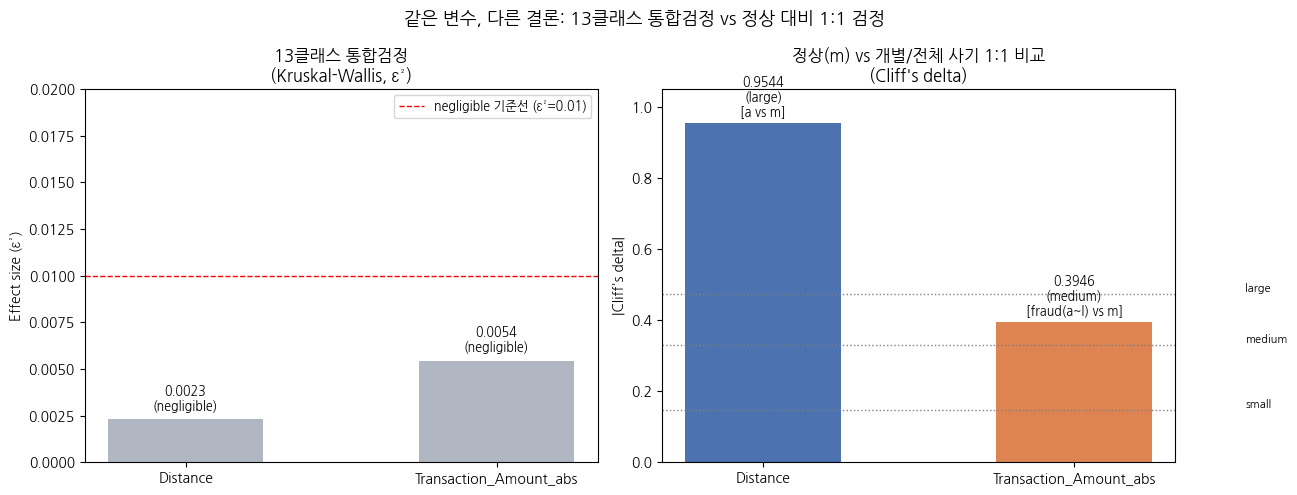

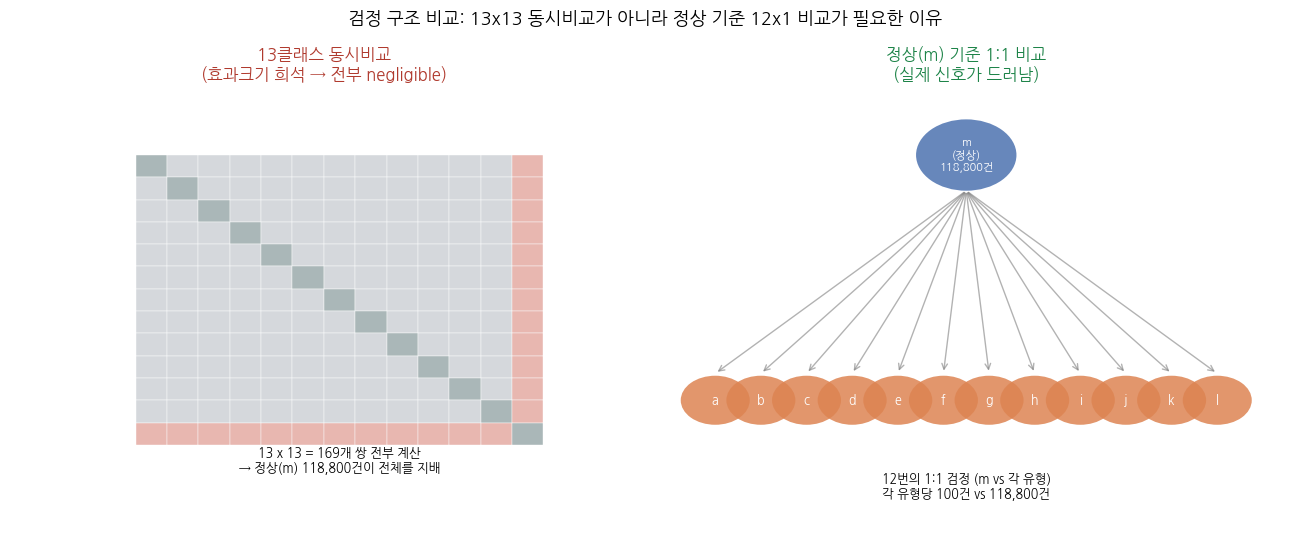

In [ ]:
# ============================================================
# 그룹 1: 방법론 핵심 발견 시각화
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
from scipy import stats

# 한글 폰트
!sudo apt-get -qq install -y fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df = train_binary  # 기존 변수 그대로 사용

# --- 파생변수 (없으면 생성) ---
if 'Transaction_Amount_abs' not in df.columns:
    df['Transaction_Amount_abs'] = df['Transaction_Amount'].abs()

# --- 효과크기 계산 함수 ---
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    u, _ = stats.mannwhitneyu(x, y, alternative='two-sided')
    return (2 * u) / (nx * ny) - 1

def epsilon_squared(groups):
    all_data = np.concatenate(groups)
    n = len(all_data)
    h_stat, p = stats.kruskal(*groups)
    eps2 = h_stat / ((n**2 - 1) / (n + 1))
    return h_stat, p, eps2

def effect_label_cliffs(d):
    d = abs(d)
    if d >= 0.474: return 'large'
    if d >= 0.33:  return 'medium'
    if d >= 0.147: return 'small'
    return 'negligible'

def effect_label_eps2(e):
    if e >= 0.14: return 'large'
    if e >= 0.06: return 'medium'
    if e >= 0.01: return 'small'
    return 'negligible'

# --- 실제 값 계산 ---
groups_distance = [df.loc[df['Fraud_Type']==t, 'Distance'].values for t in sorted(df['Fraud_Type'].unique())]
_, _, eps_distance = epsilon_squared(groups_distance)

groups_amount = [df.loc[df['Fraud_Type']==t, 'Transaction_Amount_abs'].values for t in sorted(df['Fraud_Type'].unique())]
_, _, eps_amount = epsilon_squared(groups_amount)

m_distance = df.loc[df['Fraud_Type']=='m', 'Distance'].values
a_distance = df.loc[df['Fraud_Type']=='a', 'Distance'].values
delta_a_distance = cliffs_delta(a_distance, m_distance)

fraud_amount = df.loc[df['Fraud_Type']!='m', 'Transaction_Amount_abs'].values
m_amount = df.loc[df['Fraud_Type']=='m', 'Transaction_Amount_abs'].values
delta_amount_all = cliffs_delta(fraud_amount, m_amount)

print(f"[13클래스 통합] Distance eps^2={eps_distance:.4f} ({effect_label_eps2(eps_distance)})")
print(f"[13클래스 통합] Amount_abs eps^2={eps_amount:.4f} ({effect_label_eps2(eps_amount)})")
print(f"[1:1] a vs m Distance delta={delta_a_distance:.4f} ({effect_label_cliffs(delta_a_distance)})")
print(f"[1:1] fraud(all) vs m Amount_abs delta={delta_amount_all:.4f} ({effect_label_cliffs(delta_amount_all)})")

# ============================================================
# 그림 1-A: 효과크기 비교 막대그래프
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vars_ = ['Distance', 'Transaction_Amount_abs']
eps2_vals = [eps_distance, eps_amount]
cliffs_vals = [delta_a_distance, delta_amount_all]
labels_1v1 = ['a vs m', 'fraud(a~l) vs m']

ax = axes[0]
bars = ax.bar(vars_, eps2_vals, color='#B0B7C3', width=0.5)
ax.axhline(0.01, color='red', linestyle='--', linewidth=1, label='negligible 기준선 (ε²=0.01)')
ax.set_ylim(0, max(0.02, max(eps2_vals)*1.5))
ax.set_title('13클래스 통합검정\n(Kruskal-Wallis, ε²)', fontsize=12)
ax.set_ylabel('Effect size (ε²)')
for b, v in zip(bars, eps2_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.4f}\n({effect_label_eps2(v)})', ha='center', fontsize=9)
ax.legend(fontsize=9)

ax = axes[1]
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(vars_, [abs(c) for c in cliffs_vals], color=colors, width=0.5)
for yv, lab in [(0.147,'small'), (0.33,'medium'), (0.474,'large')]:
    ax.axhline(yv, color='gray', linestyle=':', linewidth=1)
    ax.text(1.55, yv, lab, fontsize=8, va='bottom')
ax.set_ylim(0, 1.05)
ax.set_title("정상(m) vs 개별/전체 사기 1:1 비교\n(Cliff's delta)", fontsize=12)
ax.set_ylabel("|Cliff's delta|")
for b, v, lab in zip(bars, cliffs_vals, labels_1v1):
    ax.text(b.get_x()+b.get_width()/2, abs(v)+0.02, f'{v:.4f}\n({effect_label_cliffs(v)})\n[{lab}]', ha='center', fontsize=9)

fig.suptitle('같은 변수, 다른 결론: 13클래스 통합검정 vs 정상 대비 1:1 검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1a_effect_size_contrast.png', dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# 그림 1-B: 검정 구조 설명 다이어그램 (13x13이 아니라 12(유형)x1(정상))
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('13클래스 동시비교\n(효과크기 희석 → 전부 negligible)', fontsize=12, color='#B03A2E')

grid_labels = list('abcdefghijklm')
n = len(grid_labels)
size = 6.5
x0, y0 = 2, 2
step = size / n
for i, li in enumerate(grid_labels):
    for j, lj in enumerate(grid_labels):
        x = x0 + j*step
        y = y0 + size - (i+1)*step
        color = '#E8B7B0' if 'm' in (li, lj) and li != lj else ('#D5D8DC' if li != lj else '#AAB7B8')
        ax.add_patch(plt.Rectangle((x, y), step, step, facecolor=color, edgecolor='white', linewidth=0.3))
ax.text(x0 + size/2, y0 - 0.6, '13 x 13 = 169개 쌍 전부 계산\n→ 정상(m) 118,800건이 전체를 지배', ha='center', fontsize=9)

ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('정상(m) 기준 1:1 비교\n(실제 신호가 드러남)', fontsize=12, color='#1E8449')

ax.add_patch(plt.Circle((5, 8.5), 0.8, facecolor='#4C72B0', alpha=0.85))
ax.text(5, 8.5, 'm\n(정상)\n118,800건', ha='center', va='center', color='white', fontsize=8, fontweight='bold')

types = list('abcdefghijkl')
xs = np.linspace(1, 9, len(types))
for x, t in zip(xs, types):
    ax.add_patch(plt.Circle((x, 3), 0.55, facecolor='#DD8452', alpha=0.85))
    ax.text(x, 3, t, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.annotate('', xy=(x, 3.6), xytext=(5, 7.7),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.6))
ax.text(5, 0.8, '12번의 1:1 검정 (m vs 각 유형)\n각 유형당 100건 vs 118,800건',
        ha='center', fontsize=9)

fig.suptitle('검정 구조 비교: 13x13 동시비교가 아니라 정상 기준 12x1 비교가 필요한 이유', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1b_test_structure_diagram.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac: 'AppleGothic', Linux: 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

flag_cols = [
    'Customer_flag_change_of_authentication_1', 'Customer_flag_change_of_authentication_2',
    'Customer_flag_change_of_authentication_3', 'Customer_flag_change_of_authentication_4',
    'Customer_rooting_jailbreak_indicator', 'Customer_mobile_roaming_indicator',
    'Customer_VPN_Indicator', 'Customer_flag_terminal_malicious_behavior_1',
    'Customer_flag_terminal_malicious_behavior_2', 'Customer_flag_terminal_malicious_behavior_3',
    'Customer_flag_terminal_malicious_behavior_4', 'Customer_flag_terminal_malicious_behavior_5',
    'Customer_flag_terminal_malicious_behavior_6', 'Customer_inquery_atm_limit',
    'Customer_increase_atm_limit', 'Account_indicator_release_limit_excess',
    'Account_indicator_Openbanking', 'Account_release_suspention',
    'Transaction_Failure_Status', 'Another_Person_Account', 'Unused_terminal_status',
    'Flag_deposit_more_than_tenMillion', 'Unused_account_status',
    'Recipient_account_suspend_status', 'First_time_iOS_by_vulnerable_user',
    'Transaction_is_withdrawal',
]

numeric_cols = [
    'Customer_Birthyear', 'Account_initial_balance', 'Account_balance',
    'Account_amount_daily_limit', 'Account_remaining_amount_daily_limit_exceeded',
    'Account_one_month_max_amount', 'Account_one_month_std_dev',
    'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev',
    'Transaction_num_connection_failure', 'Distance',
    'Number_of_transaction_with_the_account', 'Transaction_history_with_the_account',
    'Time_difference_seconds', 'Transaction_Amount_abs',
]

categorical_cols = [
    'ID', 'Customer_Gender', 'Customer_personal_identifier', 'Customer_identification_number',
    'Customer_credit_rating', 'Customer_loan_type', 'Account_account_number',
    'Account_account_type', 'Channel', 'Operating_System', 'Error_Code',
    'Type_General_Automatic', 'IP_Address', 'MAC_Address', 'Access_Medium',
    'Location_region', 'Recipient_Account_Number',
]

# 범주형 중 식별자성(카디널리티 너무 높음) vs 분석용 자동 분리
id_like_cols = [c for c in categorical_cols if df[c].nunique() > 50]
analysis_cat_cols = [c for c in categorical_cols if c not in id_like_cols]

print('식별자성(분석 제외):', id_like_cols)
print('분석용 범주형:', analysis_cat_cols)

식별자성(분석 제외): ['ID', 'Customer_personal_identifier', 'Customer_identification_number', 'Account_account_number', 'IP_Address', 'MAC_Address', 'Recipient_Account_Number']
분석용 범주형: ['Customer_Gender', 'Customer_credit_rating', 'Customer_loan_type', 'Account_account_type', 'Channel', 'Operating_System', 'Error_Code', 'Type_General_Automatic', 'Access_Medium', 'Location_region']


### 12-2. 폰트 재설치 및 스타일 세팅

In [ ]:
# 1) 폰트 설치
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# 2) style 세팅을 먼저
sns.set_style('whitegrid')

# 3) 폰트 설정은 반드시 그 이후에, 마지막에
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
# 4) 괴리 큰 변수부터 boxplot(전체) + violin(사기끼리) 페어로 시각화
top_cols = deviation_score.head(8).index.tolist()
n = len(top_cols)

fig, axes = plt.subplots(n, 2, figsize=(16, 4 * n))

for i, col in enumerate(top_cols):
    ax_box, ax_violin = axes[i, 0], axes[i, 1]

    sns.boxplot(data=df, x='Fraud_Type', y=col, order=FRAUD_ORDER, ax=ax_box)
    ax_box.set_yscale('symlog')
    ax_box.set_title(f'{col} - 전체 (m 포함, symlog)')

    sub = df[df['Fraud_Type'] != 'm']
    sns.violinplot(data=sub, x='Fraud_Type', y=col, order=FRAUD_ONLY, ax=ax_violin, cut=0, inner='quartile')
    ax_violin.set_title(f'{col} - 사기유형(a~l)만')

plt.tight_layout()
plt.show()

NameError: name 'deviation_score' is not defined

### 12-3. 전체 개요 z-score 히트맵 (15개 변수 x 12유형)

In [ ]:
# 3) 전체 개요용 히트맵 - 15개 변수 x 12유형 괴리도(z-score) 한 장에 몰아보기
plt.figure(figsize=(12, 8))
sns.heatmap(deviation.T, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            cbar_kws={'label': '정상 대비 괴리(z-score)'})
plt.title('Fraud_Type별 수치형 변수 - 정상(m) 대비 괴리도')
plt.tight_layout()
plt.show()

### 12-4. 세부 시각화 A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

flag_cols = [
    'Customer_flag_change_of_authentication_1', 'Customer_flag_change_of_authentication_2',
    'Customer_flag_change_of_authentication_3', 'Customer_flag_change_of_authentication_4',
    'Customer_rooting_jailbreak_indicator', 'Customer_mobile_roaming_indicator',
    'Customer_VPN_Indicator', 'Customer_flag_terminal_malicious_behavior_1',
    'Customer_flag_terminal_malicious_behavior_2', 'Customer_flag_terminal_malicious_behavior_3',
    'Customer_flag_terminal_malicious_behavior_4', 'Customer_flag_terminal_malicious_behavior_5',
    'Customer_flag_terminal_malicious_behavior_6', 'Customer_inquery_atm_limit',
    'Customer_increase_atm_limit', 'Account_indicator_release_limit_excess',
    'Account_indicator_Openbanking', 'Account_release_suspention',
    'Transaction_Failure_Status', 'Unused_terminal_status',
    'Flag_deposit_more_than_tenMillion', 'Unused_account_status',
    'Recipient_account_suspend_status', 'First_time_iOS_by_vulnerable_user',
]
flag_cols = [c for c in flag_cols if df[c].nunique() > 1]

flag_rate = df.groupby('Fraud_Type')[flag_cols].mean().loc[FRAUD_ORDER]
overall = flag_rate.loc['m'].replace(0, np.nan)
flag_lift = flag_rate.div(overall, axis=1)

# 발생률 기준으로 변수 정렬(=시각적으로 패턴 잘 보이게) - 사기유형 평균 발생률 높은 순
sort_order = flag_rate.loc[FRAUD_ONLY].mean().sort_values(ascending=False).index
flag_rate_sorted = flag_rate[sort_order]
flag_lift_sorted = flag_lift[sort_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 18))

# ① 발생률 히트맵 (m 포함 전체)
sns.heatmap(flag_rate_sorted.T, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': '발생률'}, ax=axes[0])
axes[0].set_title('Fraud_Type별 플래그 발생률 (전체, m 포함)', fontsize=13)
axes[0].set_xlabel('Fraud_Type')

# ② 정상 대비 Lift 히트맵 (m 대비 몇 배인지 - 시그니처 발굴용)
sns.heatmap(flag_lift_sorted.T, annot=True, fmt='.1f', cmap='coolwarm', center=1,
            linewidths=0.5, cbar_kws={'label': '정상(m) 대비 배율'}, ax=axes[1])
axes[1].set_title('Fraud_Type별 플래그 Lift (정상=1 기준)', fontsize=13)
axes[1].set_xlabel('Fraud_Type')

plt.tight_layout()
plt.show()

### 12-5. 세부 시각화 B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

cat_cols = ['Customer_Gender','Customer_credit_rating', 'Customer_loan_type', 'Account_account_type',
            'Channel', 'Operating_System', 'Error_Code', 'Type_General_Automatic',
            'Access_Medium', 'Location_region']

def get_lift(col):
    ct = pd.crosstab(df['Fraud_Type'], df[col], normalize='index').loc[FRAUD_ORDER]
    overall = ct.loc['m'].replace(0, np.nan)
    return ct.div(overall, axis=1)

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(14, 3.2 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):
    lift = get_lift(col).loc[FRAUD_ONLY]
    sns.heatmap(lift.T, annot=True, fmt='.1f', cmap='coolwarm', center=1,
                linewidths=0.5, cbar_kws={'label': 'Lift'}, ax=ax)
    ax.set_title(f'Fraud_Type별 {col} Lift (정상=1 기준)', fontsize=12)
    ax.set_xlabel('')

axes[-1].set_xlabel('Fraud_Type')
plt.tight_layout()
plt.show()

### 12-6. ID성 컬럼 점검 (유형 간 중복 여부)

In [ ]:
id_like_cols = ['ID','Customer_personal_identifier',
                'Customer_identification_number', 'Account_account_number',
                'IP_Address', 'MAC_Address', 'Recipient_Account_Number']

In [ ]:
print(f"{'컬럼':40s} {'고유값 수':>10s} {'여러유형에 걸친 값':>18s}")
for col in id_like_cols:
    n_unique = df[col].nunique()
    dup = df.groupby(col)['Fraud_Type'].nunique()
    multi_type = (dup > 1).sum()
    print(f"{col:40s} {n_unique:>10d} {multi_type:>18d}")

# 13. 파생변수 생성

> ⚠️ **재정리 중 발견한 이슈**: 원본 코드에서 `weak_signal_composite_score` 계산 시 사용하는 `_composite_cols`가 어디서도 정의되어 있지 않아 `NameError`가 발생합니다. 아래에 d유형 약신호 후보 컬럼으로 `_composite_cols`를 정의하는 코드를 추가했습니다. 실제 의도한 컬럼 목록과 다르면 수정해주세요.

In [ ]:
# _composite_cols 정의 (원본에 누락되어 있던 부분 -- d유형 약신호 후보 컬럼들)_composite_cols = [    'Account_balance',    'Unused_terminal_status',    'unused_terminal_and_internet',    'limit_check_then_transfer',    'Account_amount_daily_limit',]

In [ ]:
import pandas as pd
import numpy as np

# ── 1. Amount_vs_monthly_max_ratio ──
# 이번 거래금액이 계좌의 평소 월간 최대거래금액 대비 얼마나 큰지
df['Amount_vs_monthly_max_ratio'] = (
    df['Transaction_Amount_abs'] / df['Account_one_month_max_amount'].replace(0, np.nan)
)

# ── 2. Amount_vs_remaining_balance ──
# 이번 거래금액이 거래 후 남은 잔액 대비 얼마나 큰지 (+1은 0으로 나누는 것 방지)
df['Amount_vs_remaining_balance'] = (
    df['Transaction_Amount_abs'] / (df['Account_balance'].clip(lower=0) + 1)
)

# ── 3. Amount_vs_daily_limit ──
# 이번 거래금액이 계좌 일일한도 대비 얼마나 큰지 (i 유형 최강 시그니처)
df['Amount_vs_daily_limit'] = (
    df['Transaction_Amount_abs'] / df['Account_amount_daily_limit'].replace(0, np.nan)
)

# ── 4. Transaction_Hour / Is_dawn ──
# 거래 발생 시각 및 새벽(0~5시) 여부
df['Transaction_Hour'] = df['Transaction_Datetime'].dt.hour
df['Is_dawn'] = ((df['Transaction_Hour'] >= 0) & (df['Transaction_Hour'] < 6)).astype(int)


# ── 5. unused_terminal_and_internet (d 유형) ──
df['unused_terminal_and_internet'] = (
    (df['Unused_terminal_status'] == 1) & (df['Channel'] == 'internet')
).astype(int)

# ── 6. limit_check_then_transfer (d 유형) ──
df['limit_check_then_transfer'] = (
    (df['Customer_inquery_atm_limit'] == 1)
    & (df['Customer_increase_atm_limit'] == 1)
    & (df['Channel'] == 'internet')
).astype(int)


_normal = df[df['Fraud_Type'] == 'm']  # 정상 기준 평균/표준편차로 z-score 계산

weak_signal_score = pd.Series(0.0, index=df.index)
for col in _composite_cols:
    mean_m, std_m = _normal[col].mean(), _normal[col].std()
    z = (df[col] - mean_m) / std_m
    weak_signal_score += z.abs()
df['weak_signal_composite_score'] = weak_signal_score

# ── 9. large_deposit_and_remote_control (e 유형) ──
df['large_deposit_and_remote_control'] = (
    (df['Flag_deposit_more_than_tenMillion'] == 1)
    & (df['Customer_flag_terminal_malicious_behavior_2'] == 1)
).astype(int)

# 14. 2차 EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트는 이미 설치되어 있다고 가정
plt.rcParams['axes.unicode_minus'] = False

FRAUD_ORDER = list('abcdefghijkl') + ['m']
FRAUD_ONLY = list('abcdefghijkl')

# ============================================================
# 1. 연속형 비율 파생변수 3종 - boxplot(전체) + violin(사기유형만)
# ============================================================
ratio_cols = ['Amount_vs_monthly_max_ratio', 'Amount_vs_remaining_balance', 'Amount_vs_daily_limit']

fig, axes = plt.subplots(len(ratio_cols), 2, figsize=(16, 4.5 * len(ratio_cols)))

for i, col in enumerate(ratio_cols):
    ax_box, ax_violin = axes[i, 0], axes[i, 1]

    sns.boxplot(data=df, x='Fraud_Type', y=col, order=FRAUD_ORDER, ax=ax_box)
    ax_box.set_yscale('log')
    ax_box.set_title(f'{col} - 전체(m 포함, log)')

    sub = df[df['Fraud_Type'] != 'm']
    sns.violinplot(data=sub, x='Fraud_Type', y=col, order=FRAUD_ONLY, ax=ax_violin, cut=0, inner='quartile')
    ax_violin.set_yscale('log')
    ax_violin.set_title(f'{col} - 사기유형(a~l)만')

plt.tight_layout()
plt.show()

# ============================================================
# 2. Is_dawn (새벽거래 비율) - 막대그래프, i 강조
# ============================================================
dawn_rate = df.groupby('Fraud_Type')['Is_dawn'].mean().loc[FRAUD_ORDER]

plt.figure(figsize=(12, 5))
colors = ['#d62728' if t == 'i' else '#4c72b0' for t in FRAUD_ORDER]
bars = plt.bar(FRAUD_ORDER, dawn_rate.values, color=colors)
plt.axhline(dawn_rate['m'], color='gray', linestyle='--', label=f"정상(m) 기준선 = {dawn_rate['m']:.2f}")
plt.title('Fraud_Type별 새벽(0~5시) 거래 비율')
plt.ylabel('새벽 거래 비율')
plt.legend()
for bar, val in zip(bars, dawn_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 3. d 유형 전용: 조합 플래그 2개 + weak_signal_composite_score
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes[:2], ['unused_terminal_and_internet', 'limit_check_then_transfer']):
    rate = df.groupby('Fraud_Type')[col].mean().loc[FRAUD_ORDER]
    colors = ['#d62728' if t == 'd' else '#4c72b0' for t in FRAUD_ORDER]
    ax.bar(FRAUD_ORDER, rate.values, color=colors)
    ax.axhline(rate['m'], color='gray', linestyle='--')
    ax.set_title(col)
    ax.set_ylabel('발생률')

sns.boxplot(data=df, x='Fraud_Type', y='weak_signal_composite_score', order=FRAUD_ORDER, ax=axes[2])
axes[2].set_title('weak_signal_composite_score (d 종합 이상신호 점수)')

plt.tight_layout()
plt.show()

# ============================================================
# 4. e 유형 전용: large_deposit_and_remote_control (e vs f/g 분리 확인)
# ============================================================
rate = df.groupby('Fraud_Type')['large_deposit_and_remote_control'].mean().loc[FRAUD_ORDER]
plt.figure(figsize=(12, 5))
colors = ['#d62728' if t == 'e' else ('#ffa600' if t in ['f', 'g'] else '#4c72b0') for t in FRAUD_ORDER]
bars = plt.bar(FRAUD_ORDER, rate.values, color=colors)
plt.axhline(rate['m'], color='gray', linestyle='--', label=f"정상(m) 기준선 = {rate['m']:.2f}")
plt.title('large_deposit_and_remote_control 발생률 (빨강=e, 주황=f/g)')
plt.legend()
for bar, val in zip(bars, rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 5. 미확정 유형(d, i) 확대 비교 - 핵심 파생변수만 정상과 대조
# ============================================================
zoom_cols = ['Amount_vs_remaining_balance', 'Amount_vs_daily_limit', 'weak_signal_composite_score']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_types = ['d', 'i', 'm']

for ax, col in zip(axes, zoom_cols):
    sub = df[df['Fraud_Type'].isin(target_types)]
    sns.boxplot(data=sub, x='Fraud_Type', y=col, order=target_types, ax=ax)
    if df[col].max() / (df[col].min() + 1e-9) > 100:
        ax.set_yscale('log')
    ax.set_title(col)

plt.suptitle('d, i vs 정상 - 핵심 파생변수 확대 비교', y=1.02)
plt.tight_layout()
plt.show()

# 15. 인코딩 및 학습/검증 전처리 파일 추출

### 15-1. 범주형 변수 인코딩`df`(전체 train + 파생변수)의 범주형(object) 컬럼을 LabelEncoder로 인코딩한다. 인코더는 `label_encoders.pkl`로 저장해 test.csv 적용 시 재사용한다.

In [ ]:
from sklearn.preprocessing import LabelEncoderimport pickletarget_col = 'Fraud_Type'# 인코딩 대상: object 타입 전체 (타깃 제외)categorical_cols = [c for c in df.select_dtypes(include='object').columns if c != target_col]print('인코딩 대상 범주형 컬럼 수:', len(categorical_cols))print(categorical_cols)label_encoders = {}for col in categorical_cols:    le = LabelEncoder()    df[col] = le.fit_transform(df[col].astype(str))    label_encoders[col] = lewith open('label_encoders.pkl', 'wb') as f:    pickle.dump(label_encoders, f)print('label_encoders.pkl 저장 완료')

### 15-2. 타깃 인코딩`Fraud_Type`(a~l, m)을 알파벳 순으로 0~12에 매핑한다 (m=12=정상). 인코더는 `le_target.pkl`로 저장한다.

In [ ]:
le_target = LabelEncoder()df['y'] = le_target.fit_transform(df[target_col])print('클래스 매핑:')for cls, code_ in zip(le_target.classes_, le_target.transform(le_target.classes_)):    print(f'  {cls} -> {code_}')with open('le_target.pkl', 'wb') as f:    pickle.dump(le_target, f)print('le_target.pkl 저장 완료')

### 15-3. 학습 제외 컬럼 정의 (식별자 / 원본 datetime / 타깃)모델 입력으로 부적절한 식별자·원본 datetime·타깃 컬럼을 제외하고 최종 피처 목록을 확정한다.

In [ ]:
drop_cols_final = [    'ID', 'Customer_personal_identifier', 'Customer_identification_number',    'Customer_registration_datetime', 'Account_account_number', 'Account_creation_datetime',    'Transaction_Datetime', 'IP_Address', 'MAC_Address', 'Location', 'Recipient_Account_Number',    'Last_atm_transaction_datetime', 'Last_bank_branch_transaction_datetime',    'Transaction_resumed_date', target_col, 'y']# 존재하는 컬럼만 필터링 (버전에 따라 일부 없을 수 있음)drop_cols_final = [c for c in drop_cols_final if c in df.columns]feature_cols = [c for c in df.columns if c not in drop_cols_final]print('최종 피처 수:', len(feature_cols))print(feature_cols)

### 15-4. 9절에서 확정한 분할(tr_idx/va_idx)로 X/y 분리9절 `StratifiedGroupKFold`로 만든 `tr_idx`, `va_idx`(고객·계좌 그룹 누수 0건, 13클래스 양쪽 존재 검증 완료)를 그대로 재사용해 `df`(파생변수까지 포함된 전체 데이터)를 학습/검증으로 분리한다.> ⚠️ 주의: `tr_idx`/`va_idx`는 9절 시점의 `train` 행 순서 기준 위치(iloc) 인덱스다. 9절 이후 어떤 셀에서도 `df`(=train 복사본)의 행을 추가/삭제/재정렬하지 않았는지 반드시 확인한 뒤 사용할 것.

In [ ]:
X = df[feature_cols]y_all = df['y']X_tr = X.iloc[tr_idx].reset_index(drop=True)X_va = X.iloc[va_idx].reset_index(drop=True)y_tr = y_all.iloc[tr_idx].reset_index(drop=True)y_va = y_all.iloc[va_idx].reset_index(drop=True)print('X_tr:', X_tr.shape)print('X_va:', X_va.shape)print('y_tr 분포:')print(y_tr.value_counts().sort_index())print('y_va 분포:')print(y_va.value_counts().sort_index())

### 15-5. 결측치 최종 점검비율형 파생변수(0으로 나누기 방지용 결측 등)에 남아있는 결측을 확인한다. LightGBM은 결측을 자체 처리하므로 별도 대치 없이 그대로 둔다.

In [ ]:
na_counts = X_tr.isna().sum()print('결측 존재 컬럼:')print(na_counts[na_counts > 0])

### 15-6. 전처리 완료 파일 저장 (parquet)이후 모델링 단계에서 바로 불러와 쓸 수 있도록 `X_tr`, `X_va`, `y_tr`, `y_va`를 parquet으로 저장한다.

In [ ]:
X_tr.to_parquet('X_tr.parquet')X_va.to_parquet('X_va.parquet')y_tr.to_frame(name='y').to_parquet('y_tr.parquet')y_va.to_frame(name='y').to_parquet('y_va.parquet')print('저장 완료: X_tr.parquet, X_va.parquet, y_tr.parquet, y_va.parquet')